# Анализ лояльности пользователей Яндекс Афиши

## Введение

В рамках проекта проводится анализ пользовательского поведения в сервисе продажи билетов. Цель исследования — понять, какие факторы влияют на количество заказов пользователей и их возврат в сервис.

В ходе работы анализируются характеристики первого заказа, поведенческие метрики пользователей, а также временные параметры и сегментация аудитории.

### Цели исследования

- Изучить структуру пользовательской базы и распределение по числу заказов  
- Определить факторы, влияющие на возврат пользователей  
- Проанализировать влияние характеристик первого заказа на дальнейшую активность  
- Оценить связь поведенческих и временных метрик с количеством заказов  
- Провести корреляционный анализ признаков профиля пользователя  
- Сформировать сегменты пользователей и выявить различия между ними  
- Сформулировать практические рекомендации для роста повторных покупок

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik

from sqlalchemy import create_engine
from dotenv import load_dotenv
from phik.report import plot_correlation_matrix

In [2]:
load_dotenv()

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME')
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

engine = create_engine(connection_string)

query = '''
SELECT
    user_id,
    device_type_canonical,
    order_id,
    created_dt_msk AS order_dt,
    created_ts_msk AS order_ts,
    currency_code,
    revenue,
    tickets_count,
    p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER (
        PARTITION BY p.user_id
        ORDER BY p.created_dt_msk
    ) AS days_since_prev,
    event_id,
    event_name_code AS event_name,
    event_type_main,
    service_name,
    region_name,
    city_name
FROM afisha.purchases p
JOIN afisha.events e USING (event_id)
JOIN afisha.city c USING (city_id)
JOIN afisha.regions r USING (region_id)
WHERE p.device_type_canonical IN ('desktop', 'mobile') AND event_type_main != 'фильм'
ORDER BY p.user_id
''' 

In [3]:
df = pd.read_sql_query(query, con=engine)
df_lines = df.shape[0]
df.head(5)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [5]:
print('Абсолютное количество пропусков')
print(df.isna().sum().sort_values(ascending=False))
print()
print('Доля пропусков')
print((df.isna().sum()/df.shape[0]).sort_values(ascending=False))

Абсолютное количество пропусков
days_since_prev          21933
device_type_canonical        0
user_id                      0
order_dt                     0
order_ts                     0
currency_code                0
order_id                     0
revenue                      0
tickets_count                0
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
dtype: int64

Доля пропусков
days_since_prev          0.075472
device_type_canonical    0.000000
user_id                  0.000000
order_dt                 0.000000
order_ts                 0.000000
currency_code            0.000000
order_id                 0.000000
revenue                  0.000000
tickets_count            0.000000
event_id                 0.000000
event_name               0.000000
event_type_main          0.000000
service_name             0.000000
region_name              0.00000

In [6]:
print('Абсолютное количество явных дубликатов')
print(df.duplicated().sum())

Абсолютное количество явных дубликатов
0


**Типы данных**
Столбцы, для которых разумно снизить размерность типа:  
- `order_id` int64
- `revenue` float64
- `tickets_count` int64
- `event_id` int64

**Пропуски**  
Присутствуют только в столбце `days_since_prev`: 21933 штук, 7.5%. Что естественно, так как есть пользователи с одним заказом.

**Явные дубликаты**  
Отсутствуют

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [7]:
df_exchange = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
df_exchange.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


In [8]:
df_exchange['data'] = pd.to_datetime(df_exchange['data']) #Преобразуем столбец к дате
df_exchange.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[us]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 11.3 KB


In [9]:
df_exchange['rate'] = df_exchange['curs']/df_exchange['nominal'] #Считаем курс в рублях за 1 тенге
df_exchange.head()

,data,nominal,curs,cdx,rate
0,2024-01-10,100,19.9391,kzt,0.199391
1,2024-01-11,100,19.7255,kzt,0.197255
2,2024-01-12,100,19.5839,kzt,0.195839
3,2024-01-13,100,19.4501,kzt,0.194501
4,2024-01-14,100,19.4501,kzt,0.194501


In [10]:
df = df.merge(df_exchange[['rate', 'data']], how='left', left_on='order_dt', right_on='data')
df.head() #Присоединяем данные о курсе по дате к основному датафрейму

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,rate,data
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,0.186972,2024-08-20
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,0.183419,2024-07-23
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,0.196475,2024-10-06
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,0.185010,2024-07-13
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,0.196648,2024-10-04


In [11]:
df['revenue_rub'] = np.where(df['currency_code'] == 'kzt', df['revenue']*df['rate'], df['revenue'])
df.head() #Пересчитываем курс для оплат в kzt

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,rate,data,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,0.186972,2024-08-20,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,0.183419,2024-07-23,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,0.196475,2024-10-06,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,0.185010,2024-07-13,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,0.196648,2024-10-04,1390.41


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [12]:
for col in ['order_id', 'tickets_count', 'event_id']: #Понижаем размерность числовых признаков
    df[col] = pd.to_numeric(df[col], downcast='integer')
for col in ['revenue', 'rate', 'revenue_rub']: 
    df[col] = pd.to_numeric(df[col], downcast='float')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


- Понизили рамерность для стоблцов: `order_id`, `tickets_count`, `event_id`, `revenue`, `rate`, `revenue_rub`
- Изменили тип стоблца: days_since_prev float-timedelta64[ns]

In [13]:
for col in ['device_type_canonical', 'service_name', 'event_type_main', 'region_name', 'city_name']:
    print(f'{col}: {df[col].unique()}')
    print() #Проверяем категориальные данные на предмет наличия неявных дубликатов 

device_type_canonical: <StringArray>
['mobile', 'desktop']
Length: 2, dtype: str

service_name: <StringArray>
[          'Край билетов',              'Мой билет',            'За билетом!',
            'Лови билет!',     'Билеты без проблем',                'Облачко',
          'Лучшие билеты',              'Прачечная',            'Быстробилет',
           'Дом культуры',         'Весь в билетах',          'Билеты в руки',
            'Тебе билет!',            'Show_ticket', 'Городской дом культуры',
                 'Яблоко',      'Билет по телефону',         'Выступления.ру',
               'Росбилет',        'Шоу начинается!',               'Мир касс',
              'Восьмёрка',              'Телебилет',          'Crazy ticket!',
                 'Реестр',         'Быстрый кассир',             'КарандашРУ',
           'Радио ticket',                'Дырокол',                'Вперёд!',
             'Кино билет',           'Цвет и билет',               'Зе Бест!',
              'Тех би

Неявных дубликатов в категориальных данных не обнаружено

In [14]:
for col in ['revenue_rub', 'tickets_count']:
    print(df[col].describe())
    print()

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64



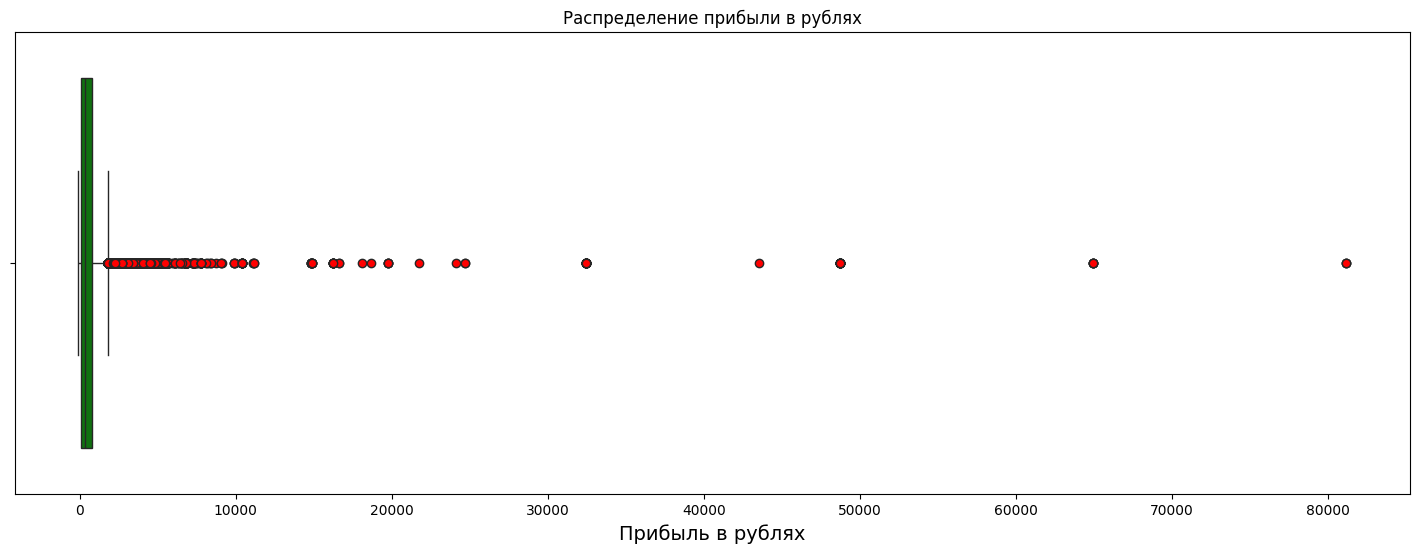

In [15]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df, x='revenue_rub', color='green', 
           flierprops={
        "marker": "o",
        "markerfacecolor": "red"
           })
plt.xlabel('Прибыль в рублях', fontsize=14)
plt.title('Распределение прибыли в рублях')
plt.show()

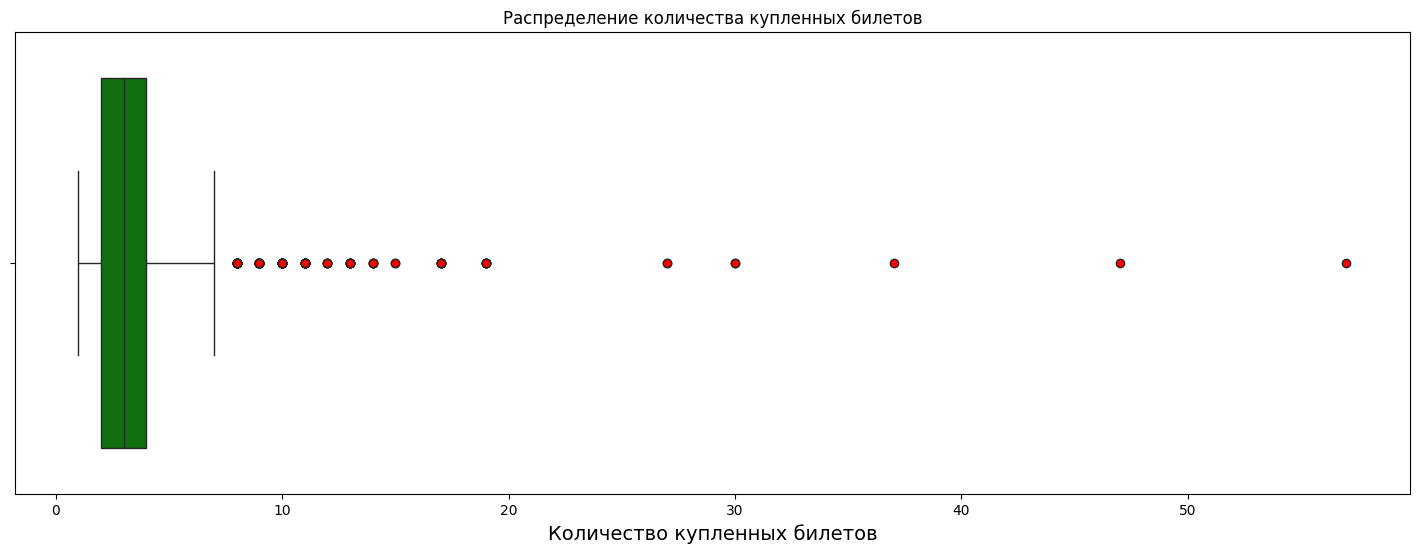

In [16]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df, x='tickets_count', color='green', 
           flierprops={
        "marker": "o",
        "markerfacecolor": "red"
           })
plt.xlabel('Количество купленных билетов', fontsize=14)
plt.title('Распределение количества купленных билетов')
plt.show()

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [18]:
df = df[df['revenue_rub']>0]
print(f'После фильтрации удалено: {df_lines-df.shape[0]} строк c revenue<=0')

После фильтрации удалено: 5907 строк c revenue<=0


**Анализ выбросов**  
Наблюдаются правосторонние выбросы в столбцах `revenue_rub` и `tickets_count`, однако большие суммы в `revenue_rub` могут быть просто покупками VIP-клиентов, поэтому их нельзя удалять, а большие покупки билетов могут быть просто закупками для корпоративов или больших мероприятий, поэтому тоже являются нормальными значениями.  

Кроме того, в колонке `revenue_rub` есть отрицательные значения, но выручка по определению не может быть отрицательной, все значения revenue<=0 были удалены (суммарно 5907 строк) после фильтрации.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [19]:
df_sorted_by_date = df.sort_values(['user_id', 'order_dt'])
df_sorted_by_date = df_sorted_by_date.drop_duplicates(subset='user_id', keep='first')
df_first_order_info = df_sorted_by_date[['user_id', 'device_type_canonical', 'region_name', 'service_name', 'event_type_main']]
df_first_order_info.head(5)

,user_id,device_type_canonical,region_name,service_name,event_type_main
0,0002849b70a3ce2,mobile,Каменевский регион,Край билетов,театр
1,0005ca5e93f2cf4,mobile,Каменевский регион,Мой билет,выставки
3,000898990054619,mobile,Североярская область,Лови билет!,другое
6,00096d1f542ab2b,desktop,Каменевский регион,Край билетов,театр
7,000a55a418c128c,mobile,Поленовский край,Лучшие билеты,театр


In [20]:
df_user_stats = df.groupby('user_id').agg(
    first_order_date=('order_dt', 'min'),
    last_order_date=('order_dt', 'max'),
    total_orders=('order_id', 'count'),
    avg_revenue=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_time_between_orders=('days_since_prev', 'mean')
)
df_user_stats = df_user_stats.reset_index()
df_user_stats.head(5)

,user_id,first_order_date,last_order_date,total_orders,avg_revenue,avg_tickets_count,avg_time_between_orders
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.0
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.0
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.0


In [21]:
df_user_profile = df_user_stats.merge(df_first_order_info, on='user_id')
df_user_profile.head(10)

,user_id,first_order_date,last_order_date,total_orders,avg_revenue,avg_tickets_count,avg_time_between_orders,device_type_canonical,region_name,service_name,event_type_main
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.000000,mobile,Каменевский регион,Мой билет,выставки
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.000000,mobile,Североярская область,Лови билет!,другое
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.000000,mobile,Поленовский край,Лучшие билеты,театр
5,000cf0659a9f40f,2024-06-20,2024-06-21,13,1175.808462,3.307692,0.083333,mobile,Широковская область,Лови билет!,концерты
6,00147c9209d45d3,2024-06-25,2024-06-25,2,352.945000,1.500000,0.000000,mobile,Каменевский регион,Облачко,концерты
7,00199a573901564,2024-06-17,2024-06-17,1,588.120000,4.000000,NaN,mobile,Каменевский регион,Билеты без проблем,концерты
8,001e7037d013f0f,2024-07-04,2024-09-29,3,326.623333,1.333333,43.500000,mobile,Златопольский округ,Мой билет,другое
9,0020c5654c92ec1,2024-07-02,2024-07-02,2,193.420000,2.000000,0.000000,mobile,Каменевский регион,Билеты без проблем,концерты


In [22]:
df_user_profile['is_two'] = np.where(df_user_profile['total_orders']>2, True, False)
df_user_profile['is_five'] = np.where(df_user_profile['total_orders']>5, True, False)
df_user_profile.head(5)

,user_id,first_order_date,last_order_date,total_orders,avg_revenue,avg_tickets_count,avg_time_between_orders,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,False,False
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,False,False


**Формирование профиль пользоваителя df_user_profile**  
Задача декомпозирована на 2 части:  
- Сбор данных по первому заказу в df_first_order_info (сортируем датафрейм по user_id и дате заказа и оставляем только первый заказ для каждого пользователя)
- Сбор статистических данных в df_user_stats  

После объединения датафреймов получаем профиль пользоваителя df_user_profile со столбцами:
- `first_order_date` - дата первого заказа;
- `last_order_date` - дата последнего заказа;
- `device_type_canonical` - устройство, с которого был сделан первый заказ;
- `region_name` - регион, в котором был сделан первый заказ;
- `service_name` - билетного партнёра, к которому обращались при первом заказе;
- `event_type_main` - жанр первого посещённого мероприятия;
- `total_orders` - общее количество заказов;
- `avg_revenue` - средняя выручка с одного заказа в рублях;
- `avg_tickets_count` - среднее количество билетов в заказе;
- `avg_time_between_orders` - среднее время между заказами.
- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [23]:
total_users = df_user_profile.shape[0]
avg_revenue = (df_user_profile['avg_revenue']*df_user_profile['total_orders']).sum()/df_user_profile['total_orders'].sum()
is_two_share = df_user_profile['is_two'].mean()
is_five_share = df_user_profile['is_five'].mean()
print('Анализ пользовательских профилей')
print(f'Общее число пользователей в выборке: {total_users:.0f}')
print(f'Средняя выручка с одного заказа: {avg_revenue:.2f} рублей')
print(f'Доля пользователей, совершивших 2 и более заказов: {is_two_share:.2f}')
print(f'Доля пользователей, совершивших 5 и более заказов: {is_five_share:.2f}')

Анализ пользовательских профилей
Общее число пользователей в выборке: 21779
Средняя выручка с одного заказа: 567.10 рублей
Доля пользователей, совершивших 2 и более заказов: 0.45
Доля пользователей, совершивших 5 и более заказов: 0.25


In [24]:
print('Статистические показатели по общему числу заказов:')
print(df_user_profile['total_orders'].describe())
print('Статистические показатели по среднему числу билетов в заказе:')
print(df_user_profile['avg_tickets_count'].describe())
print('Статистические показатели по среднему количеству дней между покупками:')
print(df_user_profile['avg_time_between_orders'].describe())

Статистические показатели по общему числу заказов:
count    21779.000000
mean        13.072409
std        120.569323
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10057.000000
Name: total_orders, dtype: float64
Статистические показатели по среднему числу билетов в заказе:
count    21779.000000
mean         2.758935
std          0.921939
min          1.000000
25%          2.000000
50%          2.772727
75%          3.142857
max         12.000000
Name: avg_tickets_count, dtype: float64
Статистические показатели по среднему количеству дней между покупками:
count    13495.000000
mean        15.873289
std         22.293580
min          0.000000
25%          1.000000
50%          8.062500
75%         20.500000
max        148.000000
Name: avg_time_between_orders, dtype: float64


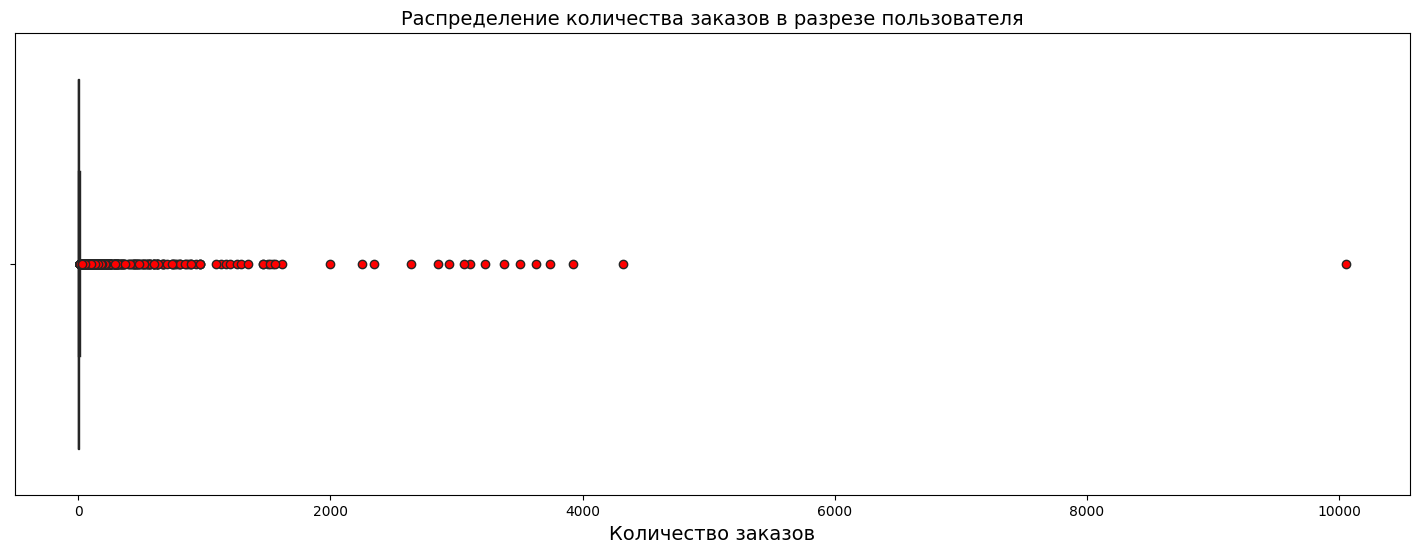

In [25]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df_user_profile, x='total_orders', color='green', flierprops={
    'marker' : 'o',
    'markerfacecolor' : 'red'
})
plt.xlabel('Количество заказов', fontsize=14)
plt.title('Распределение количества заказов в разрезе пользователя', fontsize=14)
plt.show()
lines_with_orders = df_user_profile.shape[0]

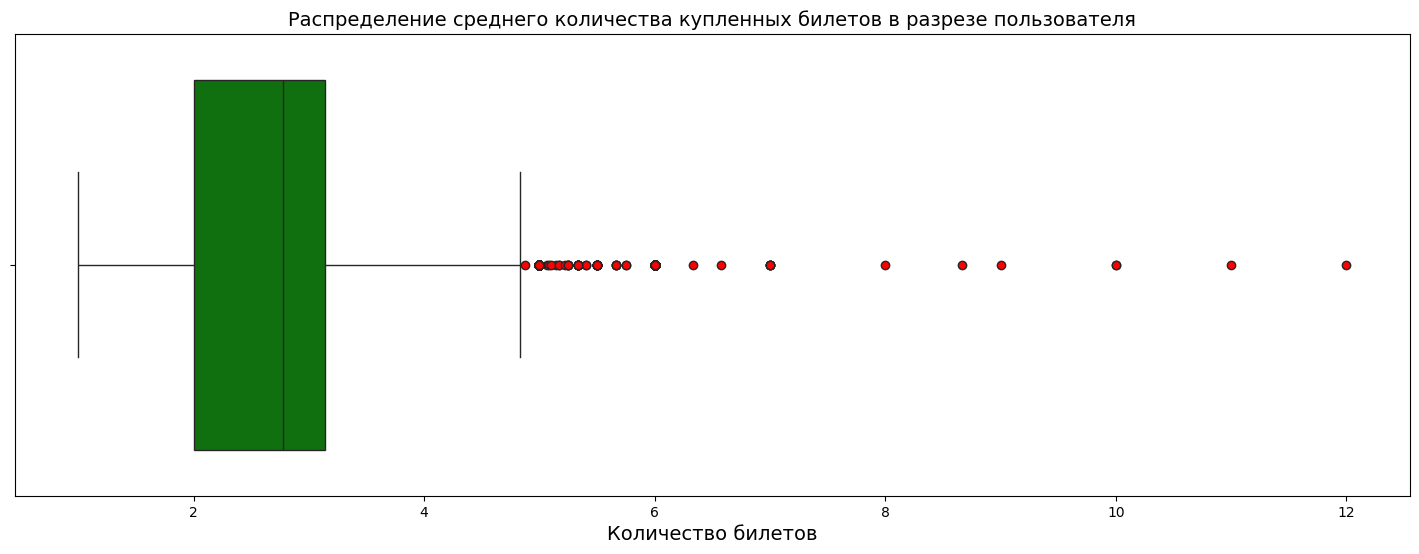

In [26]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df_user_profile, x='avg_tickets_count', color='green', flierprops={
    'marker' : 'o',
    'markerfacecolor' : 'red'
})
plt.xlabel('Количество билетов', fontsize=14)
plt.title('Распределение среднего количества купленных билетов в разрезе пользователя', fontsize=14)
plt.show()

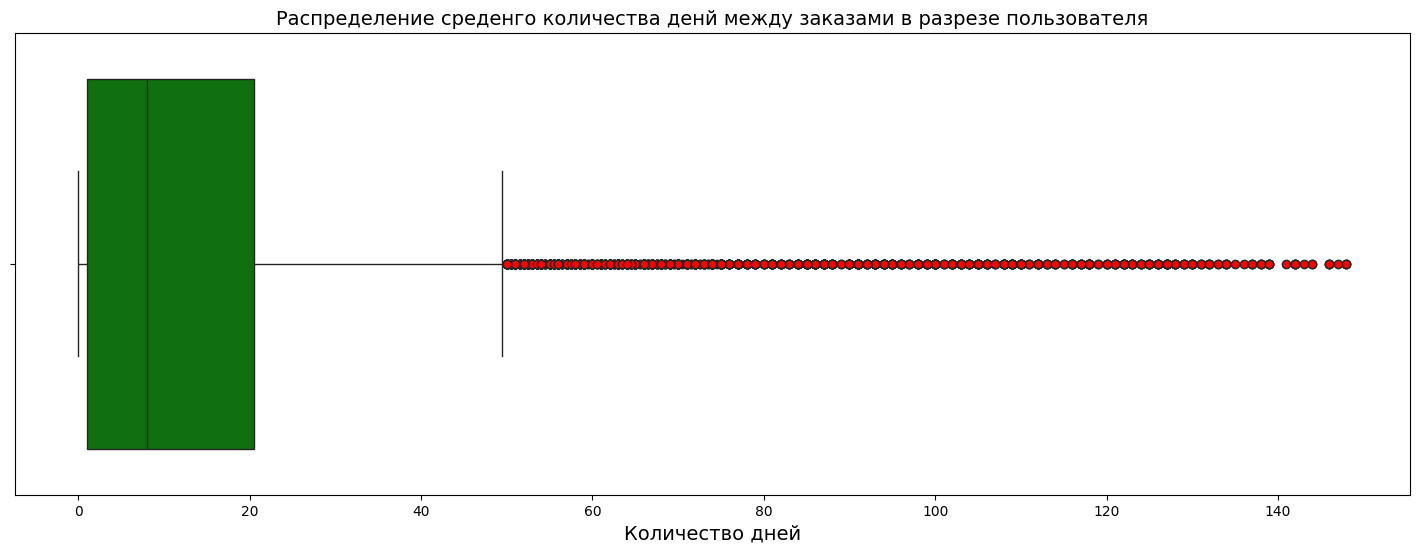

In [27]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df_user_profile, x='avg_time_between_orders', color='green', flierprops={
    'marker' : 'o',
    'markerfacecolor' : 'red'
})
plt.xlabel('Количество дней', fontsize=14)
plt.title('Распределение среденго количества денй между заказами в разрезе пользователя', fontsize=14)
plt.show()

In [28]:
df_user_profile_99 = df_user_profile[df_user_profile['total_orders']<=df_user_profile['total_orders'].quantile(0.99)]
df_user_profile_95 = df_user_profile[df_user_profile['total_orders']<=df_user_profile['total_orders'].quantile(0.95)]
print('Фильтрация данных по среднему количеству заказов пользователя по 99 перцентилю:')
print(df_user_profile_99['total_orders'].describe())
print('Фильтрация данных по среднему количеству заказов пользователя по 95 перцентилю:')
print(df_user_profile_95['total_orders'].describe())

Фильтрация данных по среднему количеству заказов пользователя по 99 перцентилю:
count    21562.000000
mean         6.445784
std         14.098916
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        152.000000
Name: total_orders, dtype: float64
Фильтрация данных по среднему количеству заказов пользователя по 95 перцентилю:
count    20700.000000
mean         4.050773
std          5.105466
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         31.000000
Name: total_orders, dtype: float64


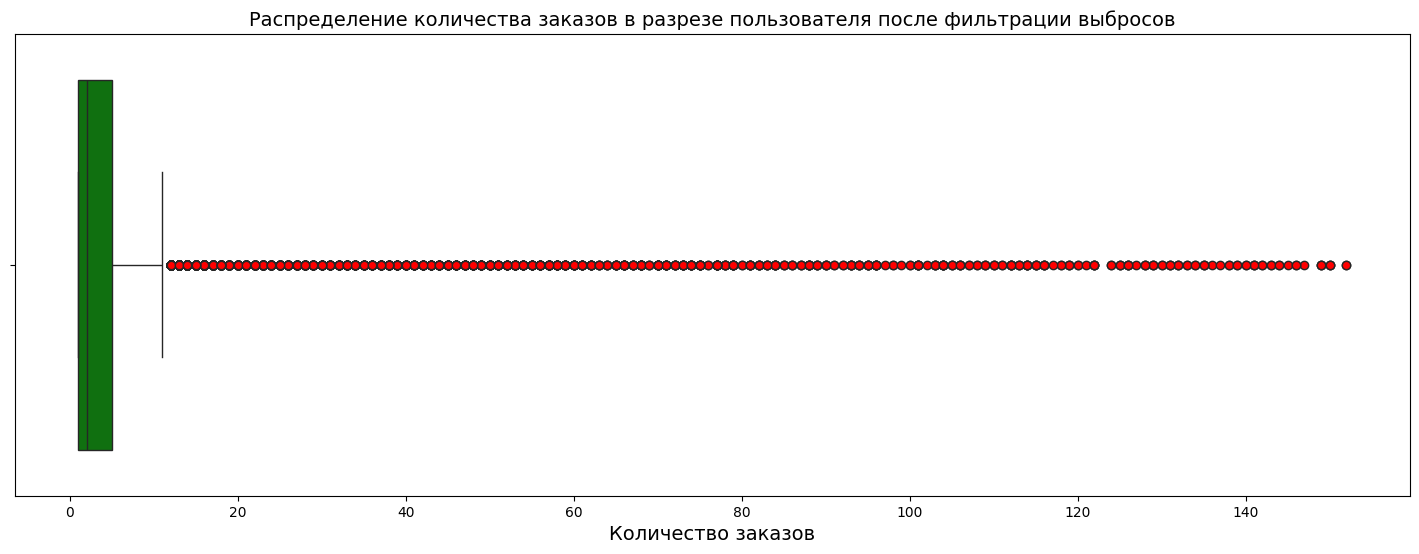

Удалено: 217 строк
Текущий размер датасета: 21562 строк


In [29]:
df_user_profile = df_user_profile[df_user_profile['total_orders']<=df_user_profile['total_orders'].quantile(0.99)]
plt.figure(figsize=(18, 6))
sns.boxplot(data=df_user_profile, x='total_orders', color='green', flierprops={
    'marker' : 'o',
    'markerfacecolor' : 'red'
})
plt.xlabel('Количество заказов', fontsize=14)
plt.title('Распределение количества заказов в разрезе пользователя после фильтрации выбросов', fontsize=14)
plt.show()
print(f'Удалено: {lines_with_orders-df_user_profile.shape[0]} строк')
print(f'Текущий размер датасета: {df_user_profile.shape[0]} строк')


Данные суммарно есть по 21779 пользователям, аномальные значения по среднему количеству билетов и по среднему количеству дней между покупками отсутствуют.  
Аномальные данные присутствуют в среднем количестве заказов на пользователя `total_orders`, наблюдается значительное количество выбросов справа, а также аномальные выбросы с количетсвом заказов 1500-10000, составляющие меньше одного процента от выборки. Для удаления выбросов была произведена фильтрация по 99 перцентилю. (были сравнены фильтрации по 99 и по 95 перцентилю и фильтрация по 99 перцентилю признана более разумной, так как 152 вполне нормальное количество заказов) 

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


event_type_main
концерты    9669
другое      5225
театр       4269
стендап     1117
спорт        773
выставки     412
ёлки          97
Name: user_id, dtype: int64


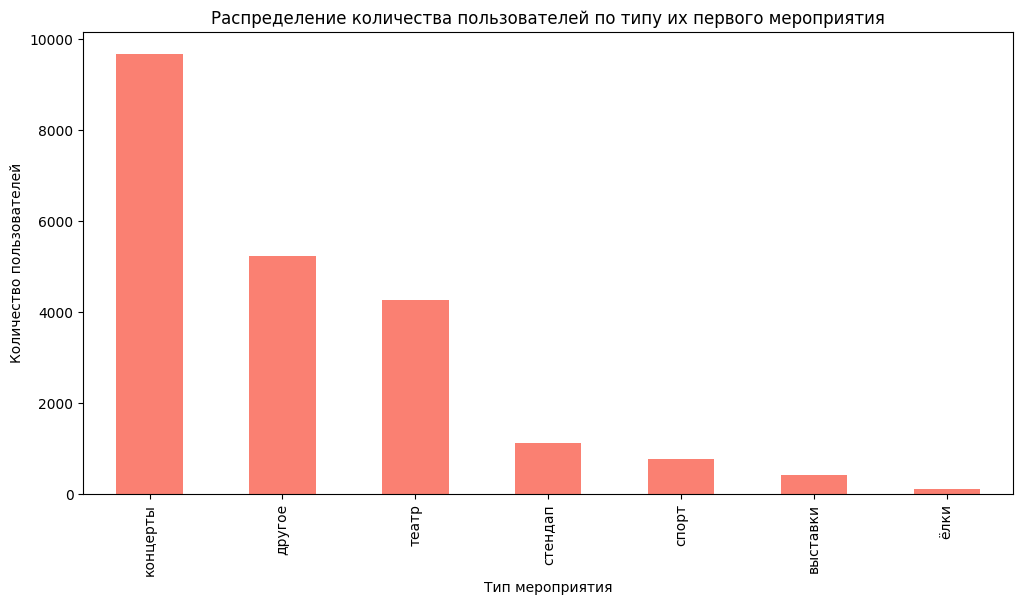

event_type_main
концерты    0.448428
другое      0.242324
театр       0.197987
стендап     0.051804
спорт       0.035850
выставки    0.019108
ёлки        0.004499
Name: user_id, dtype: float64


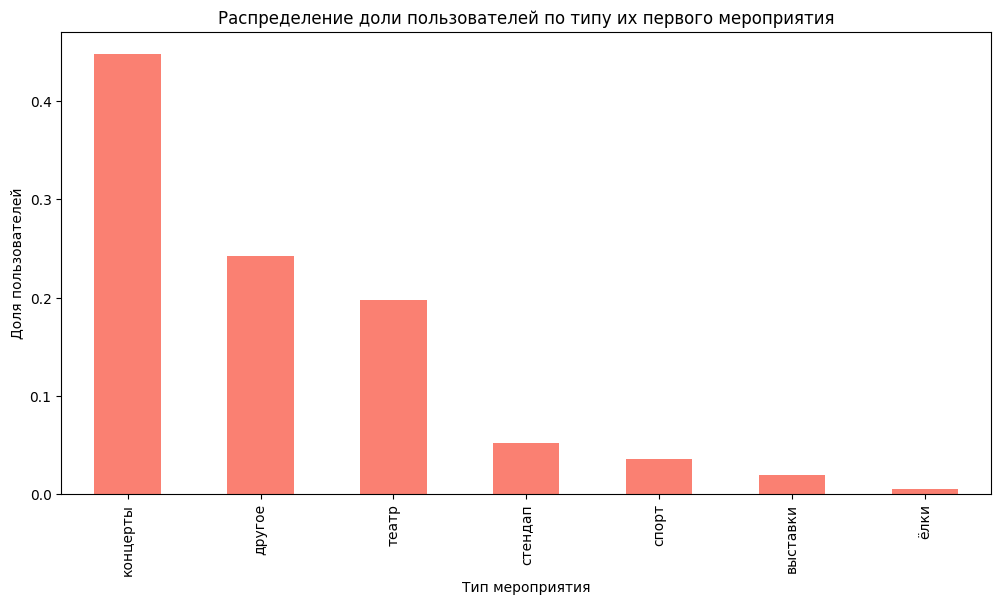

In [30]:
df_user_event_type = df_user_profile.groupby('event_type_main')['user_id'].count().sort_values(ascending=False)

print(df_user_event_type)

plt.figure(figsize=(12, 6))
df_user_event_type.plot(kind='bar', color='salmon')
plt.title('Распределение количества пользователей по типу их первого мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Количество пользователей')
plt.show()

df_user_event_type_share = ((df_user_profile.groupby('event_type_main')['user_id'].count())/df_user_profile.shape[0]).sort_values(ascending=False)

print(df_user_event_type_share)

plt.figure(figsize=(12, 6))
df_user_event_type_share.plot(kind='bar', color='salmon')
plt.title('Распределение доли пользователей по типу их первого мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля пользователей')
plt.show()

device_type_canonical
mobile     17834
desktop     3728
Name: user_id, dtype: int64


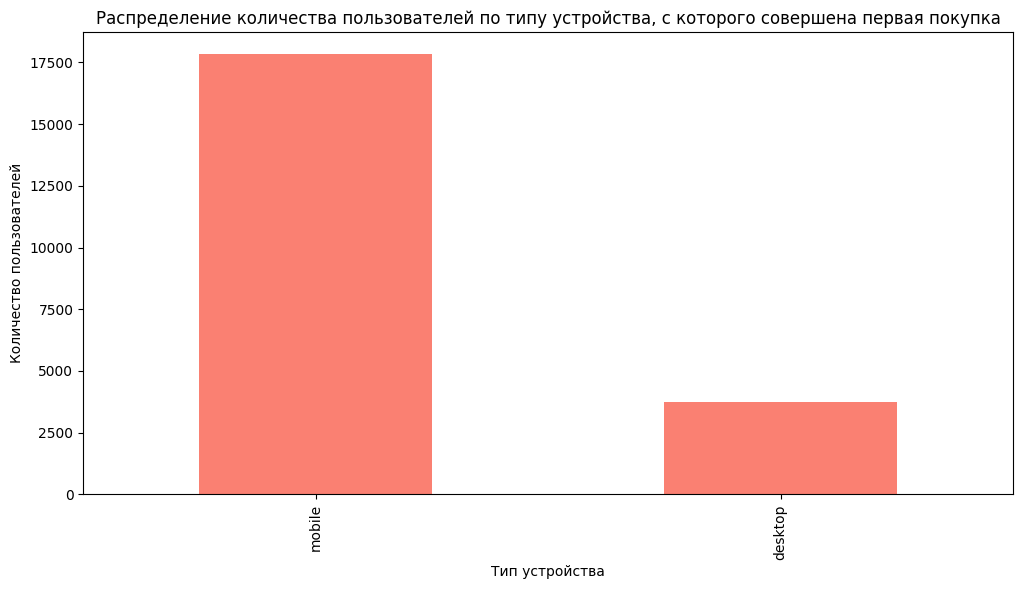

device_type_canonical
mobile     0.827103
desktop    0.172897
Name: user_id, dtype: float64


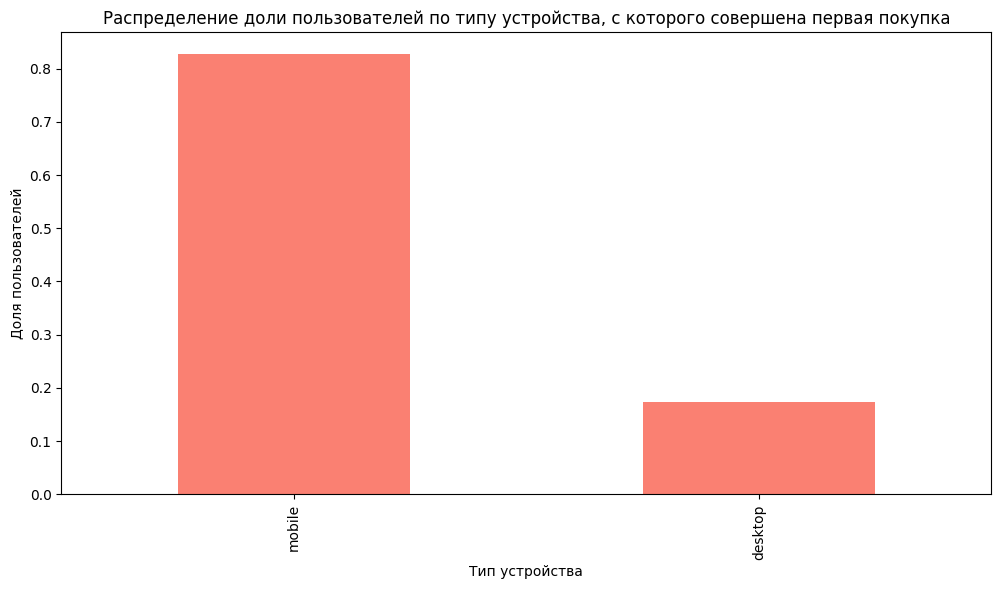

In [31]:
df_user_device_type = df_user_profile.groupby('device_type_canonical')['user_id'].count().sort_values(ascending=False)

print(df_user_device_type)

plt.figure(figsize=(12, 6))
df_user_device_type.plot(kind='bar', color='salmon')
plt.title('Распределение количества пользователей по типу устройства, с которого совершена первая покупка')
plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')
plt.show()

df_user_device_type_share = ((df_user_profile.groupby('device_type_canonical')['user_id'].count())/df_user_profile.shape[0]).sort_values(ascending=False)

print(df_user_device_type_share)

plt.figure(figsize=(12, 6))
df_user_device_type_share.plot(kind='bar', color='salmon')
plt.title('Распределение доли пользователей по типу устройства, с которого совершена первая покупка')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей')
plt.show()

region_name
Каменевский регион          7027
Североярская область        3779
Широковская область         1238
Озернинский край             682
Малиновоярский округ         535
                            ... 
Залесский край                 2
Тихогорская область            2
Верхозёрский край              1
Сосноводолинская область       1
Яснопольский округ             1
Name: user_id, Length: 81, dtype: int64


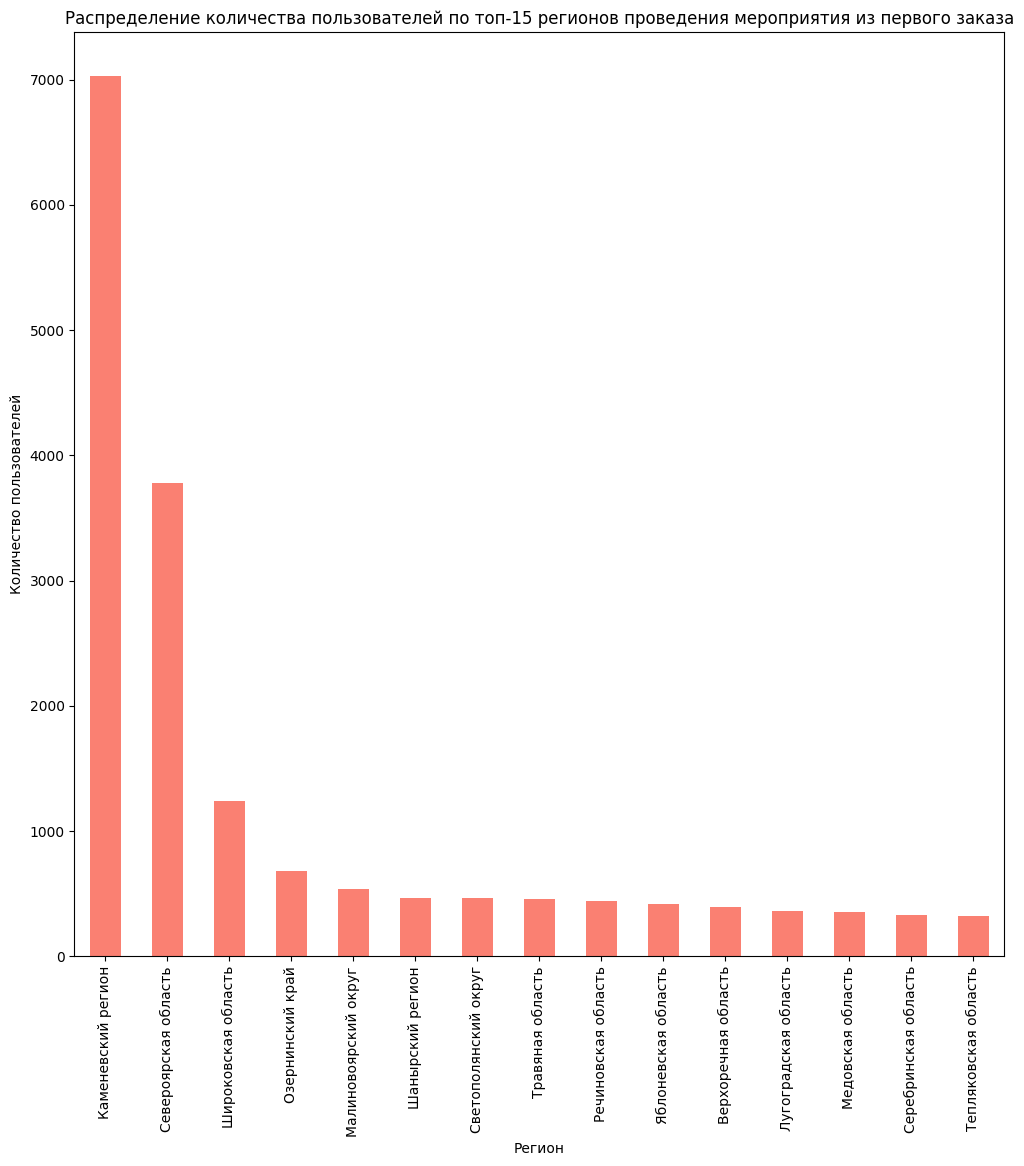

region_name
Каменевский регион          0.325897
Североярская область        0.175262
Широковская область         0.057416
Озернинский край            0.031630
Малиновоярский округ        0.024812
                              ...   
Залесский край              0.000093
Тихогорская область         0.000093
Верхозёрский край           0.000046
Сосноводолинская область    0.000046
Яснопольский округ          0.000046
Name: user_id, Length: 81, dtype: float64


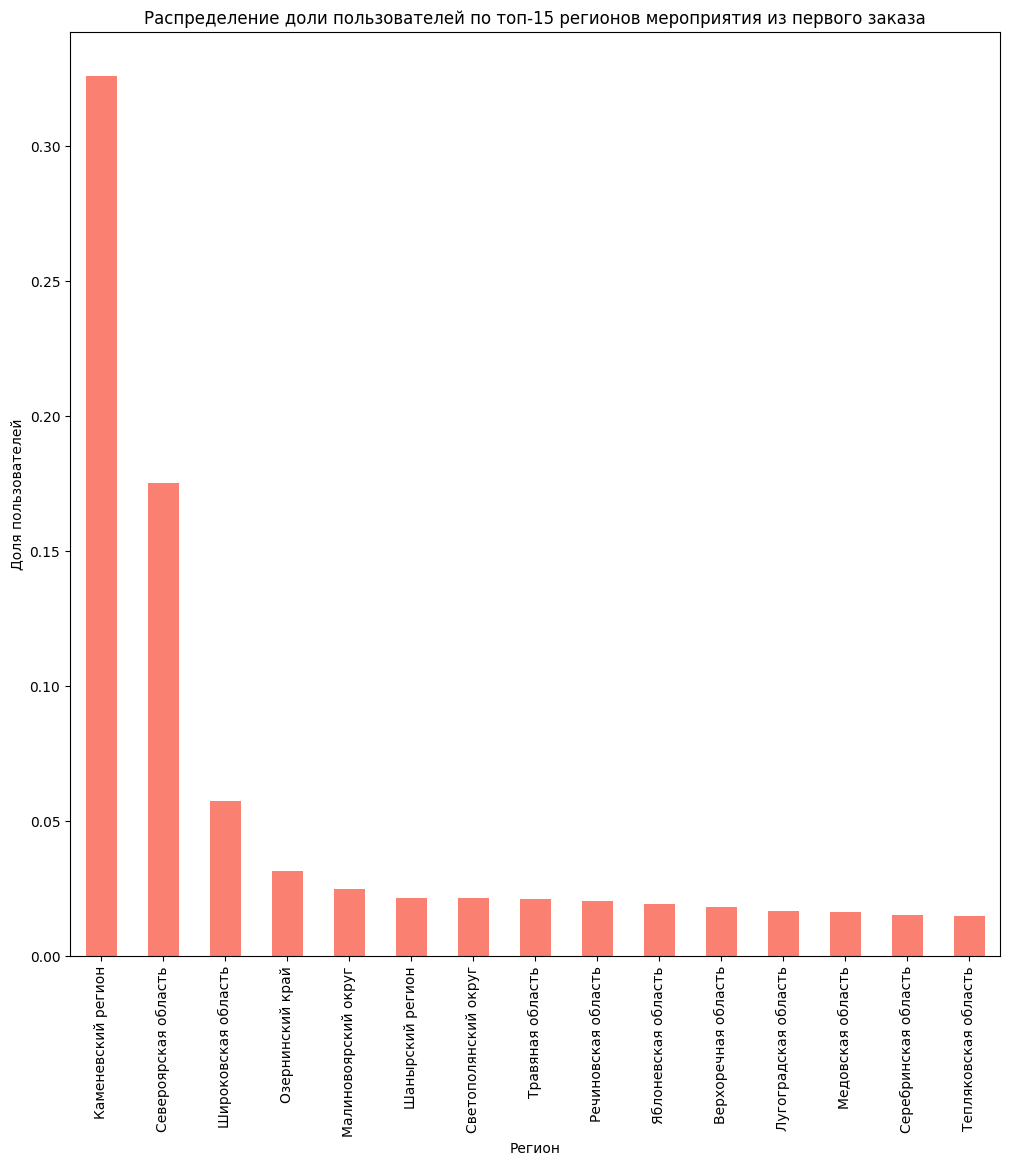

In [32]:
df_user_region = df_user_profile.groupby('region_name')['user_id'].count().sort_values(ascending=False)

print(df_user_region)

plt.figure(figsize=(12, 12))
df_user_region.head(15).plot(kind='bar', color='salmon')
plt.title('Распределение количества пользователей по топ-15 регионов проведения мероприятия из первого заказа')
plt.xlabel('Регион')
plt.ylabel('Количество пользователей')
plt.show()

df_user_region_share = ((df_user_profile.groupby('region_name')['user_id'].count())/df_user_profile.shape[0]).sort_values(ascending=False)

print(df_user_region_share)

plt.figure(figsize=(12, 12))
df_user_region_share.head(15).plot(kind='bar', color='salmon')
plt.title('Распределение доли пользователей по топ-15 регионов мероприятия из первого заказа')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей')
plt.show()

service_name
Билеты без проблем        4963
Мой билет                 3030
Лови билет!               2803
Билеты в руки             2545
Облачко                   2199
Весь в билетах            1300
Лучшие билеты             1188
Прачечная                  587
Край билетов               463
Дом культуры               354
Яблоко                     319
Тебе билет!                312
Городской дом культуры     221
За билетом!                211
Мир касс                   207
Show_ticket                168
Быстробилет                165
Выступления.ру              99
Восьмёрка                   87
Быстрый кассир              60
Росбилет                    50
Crazy ticket!               49
Радио ticket                36
Реестр                      31
Телебилет                   27
Цвет и билет                24
Шоу начинается!             20
КарандашРУ                  15
Кино билет                   9
Вперёд!                      7
Билет по телефону            6
Тех билет                 

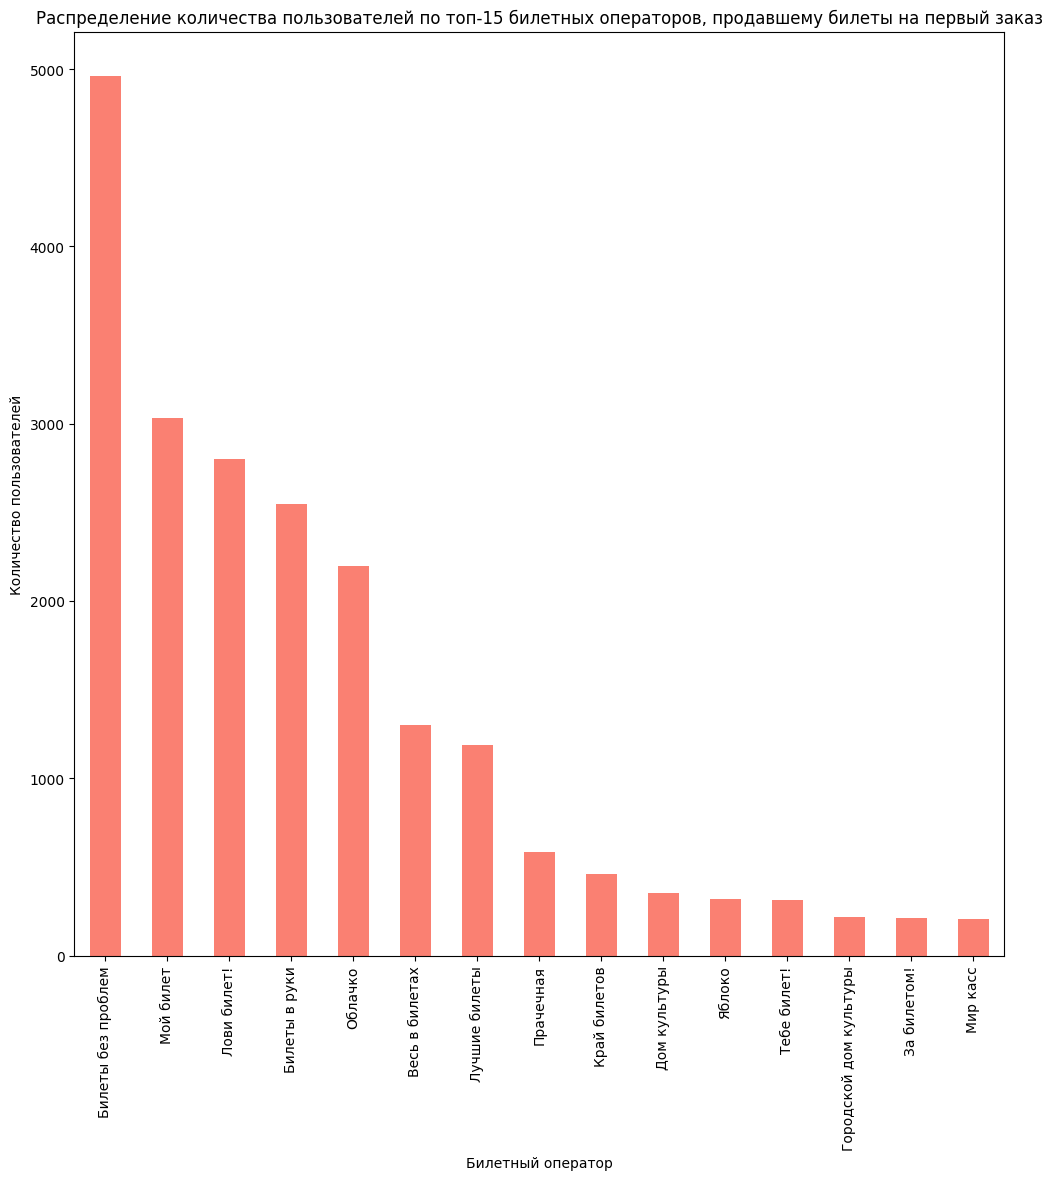

service_name
Билеты без проблем        0.230173
Мой билет                 0.140525
Лови билет!               0.129997
Билеты в руки             0.118032
Облачко                   0.101985
Весь в билетах            0.060291
Лучшие билеты             0.055097
Прачечная                 0.027224
Край билетов              0.021473
Дом культуры              0.016418
Яблоко                    0.014795
Тебе билет!               0.014470
Городской дом культуры    0.010250
За билетом!               0.009786
Мир касс                  0.009600
Show_ticket               0.007791
Быстробилет               0.007652
Выступления.ру            0.004591
Восьмёрка                 0.004035
Быстрый кассир            0.002783
Росбилет                  0.002319
Crazy ticket!             0.002273
Радио ticket              0.001670
Реестр                    0.001438
Телебилет                 0.001252
Цвет и билет              0.001113
Шоу начинается!           0.000928
КарандашРУ                0.000696
Кино би

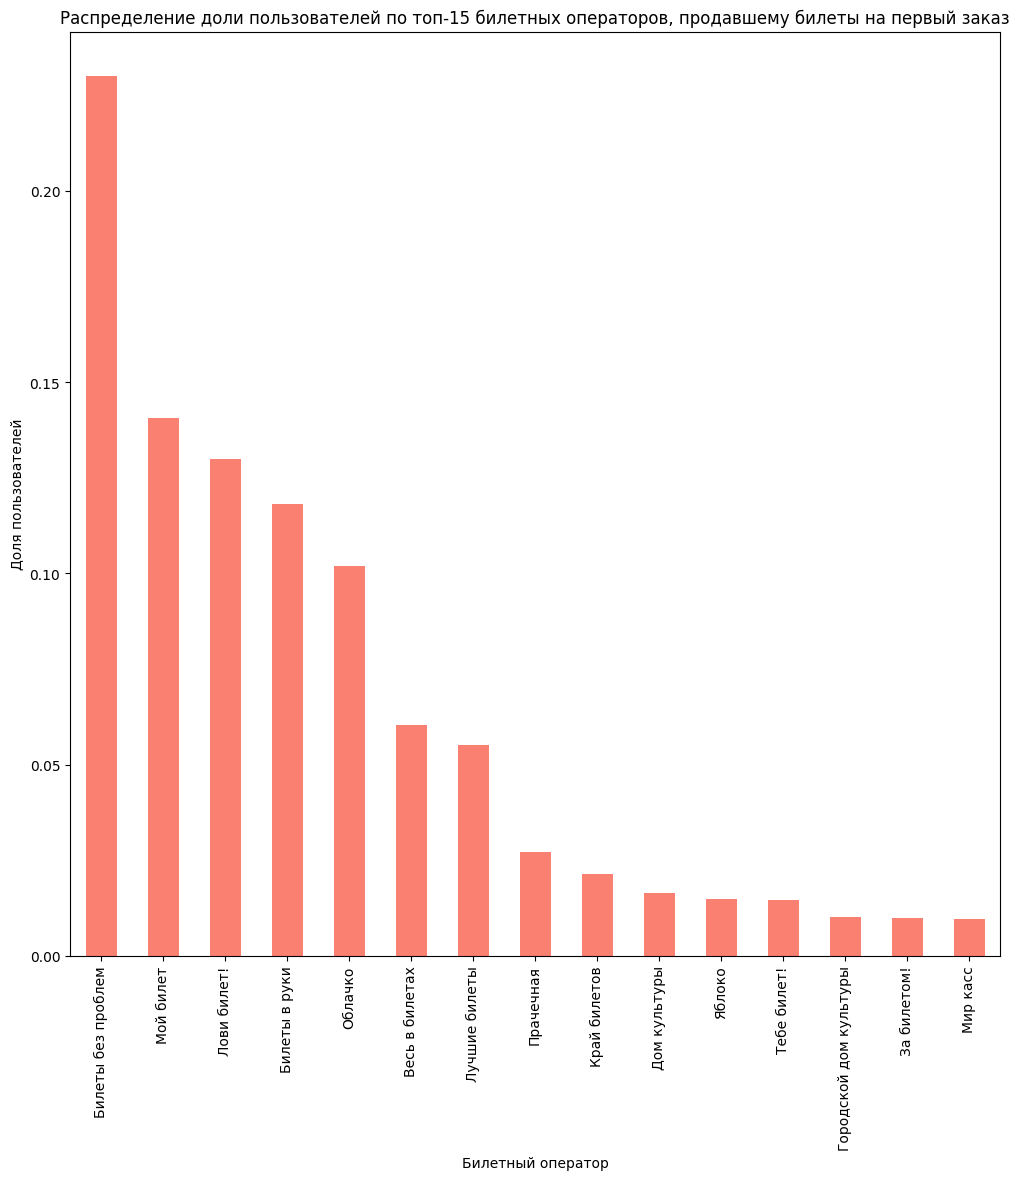

In [33]:
df_user_service = df_user_profile.groupby('service_name')['user_id'].count().sort_values(ascending=False)

print(df_user_service)

plt.figure(figsize=(12, 12))
df_user_service.head(15).plot(kind='bar', color='salmon')
plt.title('Распределение количества пользователей по топ-15 билетных операторов, продавшему билеты на первый заказ')
plt.xlabel('Билетный оператор')
plt.ylabel('Количество пользователей')
plt.show()

df_user_service_share = ((df_user_profile.groupby('service_name')['user_id'].count())/df_user_profile.shape[0]).sort_values(ascending=False)

print(df_user_service_share)

plt.figure(figsize=(12, 12))
df_user_service_share.head(15).plot(kind='bar', color='salmon')
plt.title('Распределение доли пользователей по топ-15 билетных операторов, продавшему билеты на первый заказ')
plt.xlabel('Билетный оператор')
plt.ylabel('Доля пользователей')
plt.show()

**Тип первого мероприятия**  
- концерты 45%
- другое 24%
- театр 20%

**Тип устройства первой покупки**  
- mobile 83%

**Регион проведения мероприятия из первого заказа**
- Каменевский регион 33%
- Североярская область 18%

**Билетный оператор, продавший билеты на первый заказ**
- Билеты без проблем 23%
- Мой билет 14%
- Лови билет! 13%
- Билеты в руки 12%
- Облачко 10%

**Итоговый вывод**

**Распределение пользователей по сегментам выраженно неравномерно — наблюдаются чёткие «точки входа» в продукт.**

Основной поток пользователей формируется за счёт:

- концертов как ключевого типа первого мероприятия;
- мобильных устройств как доминирующего канала первой покупки (~83%);
- отдельных регионов с высокой концентрацией спроса;
- группы лидирующих билетных операторов, через которых проходит значительная часть первых заказов.  
Это указывает на концентрацию пользовательского привлечения в ограниченном числе каналов и категорий, а не равномерное распределение по всем сегментам.

**Интерпретация**
- концерты выступают главным драйвером первичного вовлечения;
- мобильный канал — основной вход в продукт, что критично для UX и маркетинга;
- региональная концентрация может отражать как рыночную структуру, так и фокус маркетинговых активностей;
- распределение по операторам показывает наличие конкурентной среды с несколькими ключевыми игроками.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


event_type_main
театр       0.464277
концерты    0.454028
выставки    0.439320
другое      0.439234
стендап     0.435989
ёлки        0.391753
спорт       0.388098
Name: is_two, dtype: float64


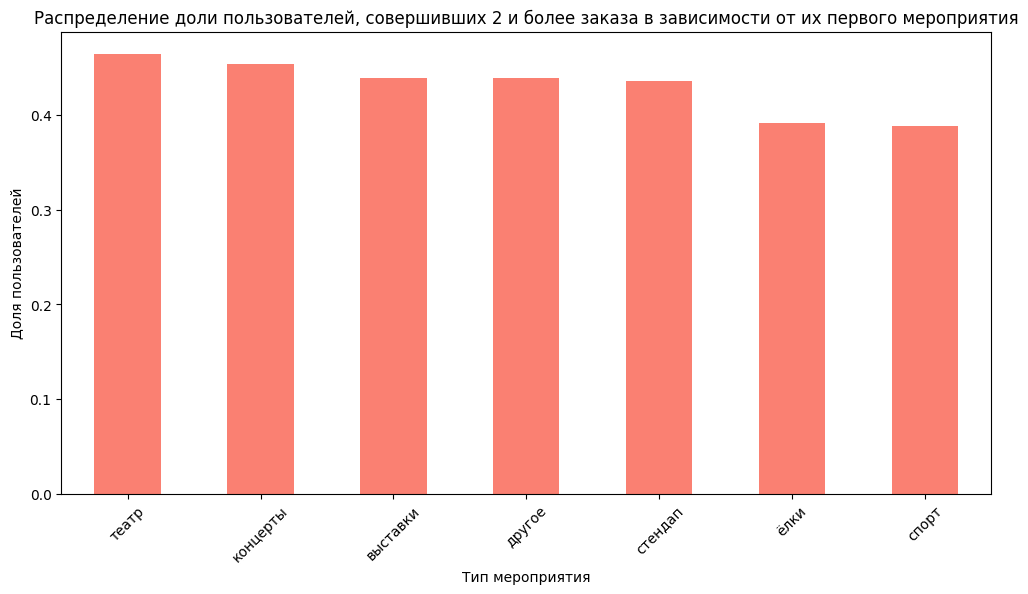

In [34]:
df_user_event_type_share_is_two = df_user_profile.groupby('event_type_main')['is_two'].mean().sort_values(ascending=False)

print(df_user_event_type_share_is_two)

plt.figure(figsize=(12, 6))
df_user_event_type_share_is_two.plot(kind='bar', color='salmon', rot=45)
plt.title('Распределение доли пользователей, совершивших 2 и более заказа в зависимости от их первого мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля пользователей')
plt.show()

device_type_canonical
desktop    0.478809
mobile     0.442301
Name: is_two, dtype: float64


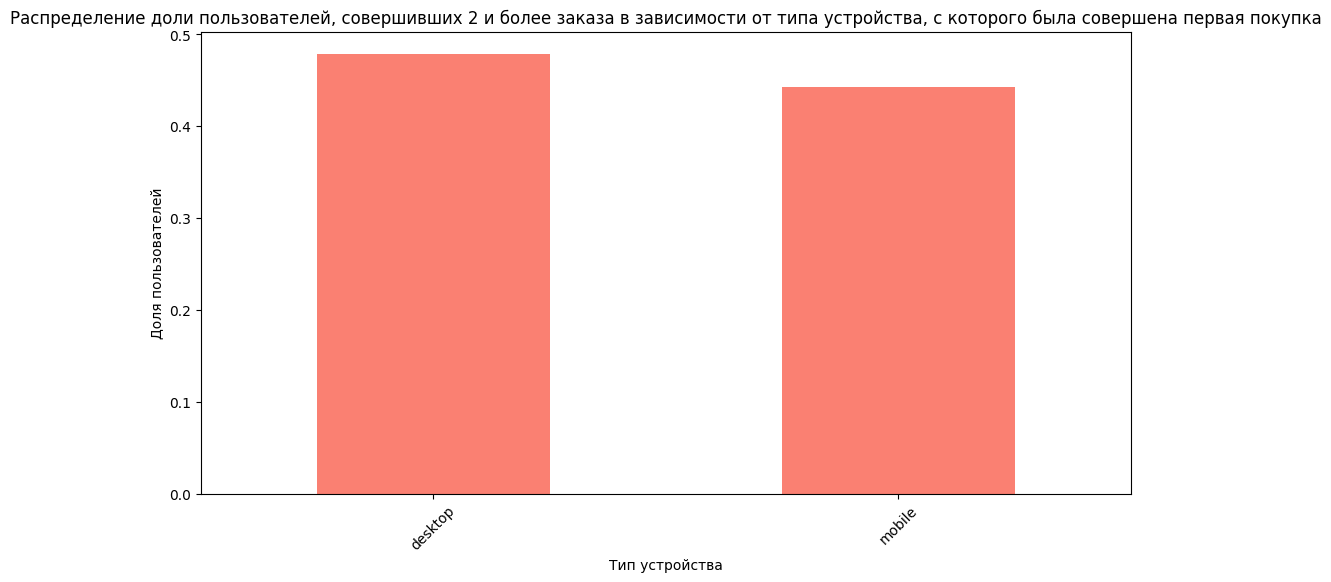

In [35]:
df_user_device_type_share_is_two = df_user_profile.groupby('device_type_canonical')['is_two'].mean().sort_values(ascending=False)

print(df_user_device_type_share_is_two)

plt.figure(figsize=(12, 6))
df_user_device_type_share_is_two.plot(kind='bar', color='salmon', rot=45)
plt.title('Распределение доли пользователей, совершивших 2 и более заказа в зависимости от типа устройства, с которого была совершена первая покупка')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей')
plt.show()

                        share_is_two  users_count
service_name                                     
Быстрый кассир              0.666667           60
Восьмёрка                   0.563218           87
Край билетов                0.522678          463
Выступления.ру              0.494949           99
Дом культуры                0.471751          354
Билеты в руки               0.471120         2545
Прачечная                   0.470187          587
Лучшие билеты               0.462121         1188
Мир касс                    0.454106          207
Городской дом культуры      0.452489          221
Весь в билетах              0.447692         1300
Show_ticket                 0.446429          168
Мой билет                   0.445215         3030
Билеты без проблем          0.442474         4963
Лови билет!                 0.438816         2803
Облачко                     0.432469         2199
Быстробилет                 0.430303          165
Росбилет                    0.420000           50


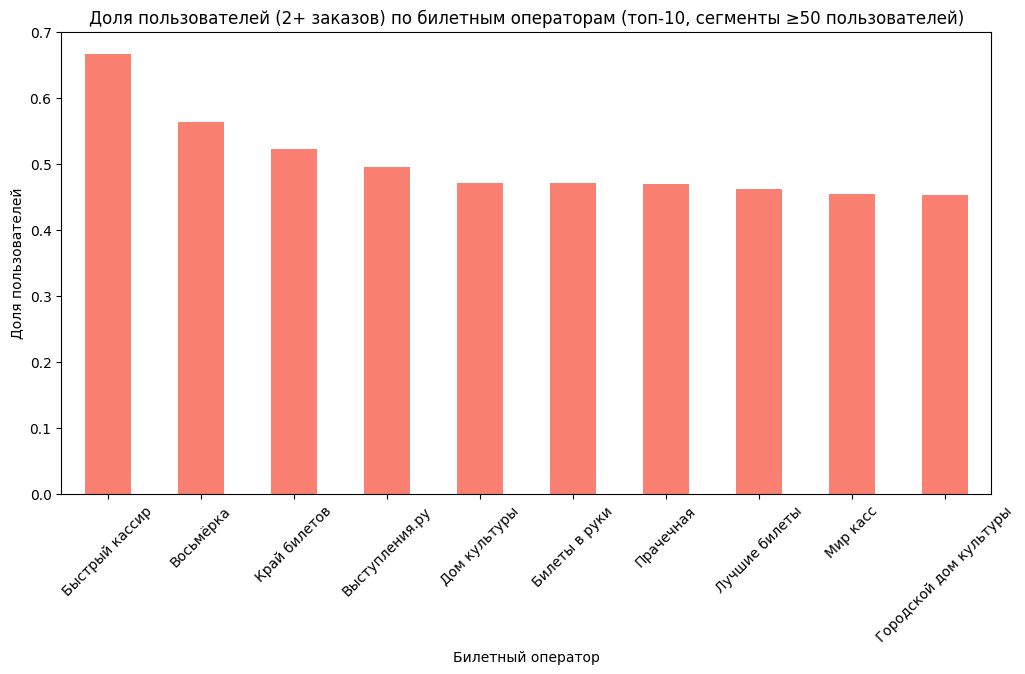

In [36]:
df_user_service = (
    df_user_profile.groupby('service_name').agg(
        share_is_two=('is_two', 'mean'),
        users_count=('user_id', 'count')
    )
)

df_user_service = df_user_service[df_user_service['users_count'] >= 50]

df_user_service = df_user_service.sort_values(by='share_is_two', ascending=False)

print(df_user_service)
print(df_user_service.describe())

plt.figure(figsize=(12, 6))
df_user_service['share_is_two'].head(10).plot(kind='bar', color='salmon', rot=45)
plt.title('Доля пользователей (2+ заказов) по билетным операторам (топ-10, сегменты ≥50 пользователей)')
plt.xlabel('Билетный оператор')
plt.ylabel('Доля пользователей')
plt.show()

                           share_is_two  users_count
region_name                                         
Лесостепной край               0.573770           61
Шанырский регион               0.553648          466
Берёзовская область            0.537037          108
Заречная область               0.526316          209
Речицкий регион                0.518519          189
Горицветская область           0.516260          246
Североярская область           0.485049         3779
Светополянский округ           0.475269          465
Североключевской округ         0.474576           59
Ветренский регион              0.470588          153
Широковская область            0.458805         1238
Каменевский регион             0.457236         7027
Лесодальний край               0.455959          193
Речиновская область            0.453303          439
Каменноозёрный край            0.452830          106
Тепляковская область           0.450311          322
Травяная область               0.443478       

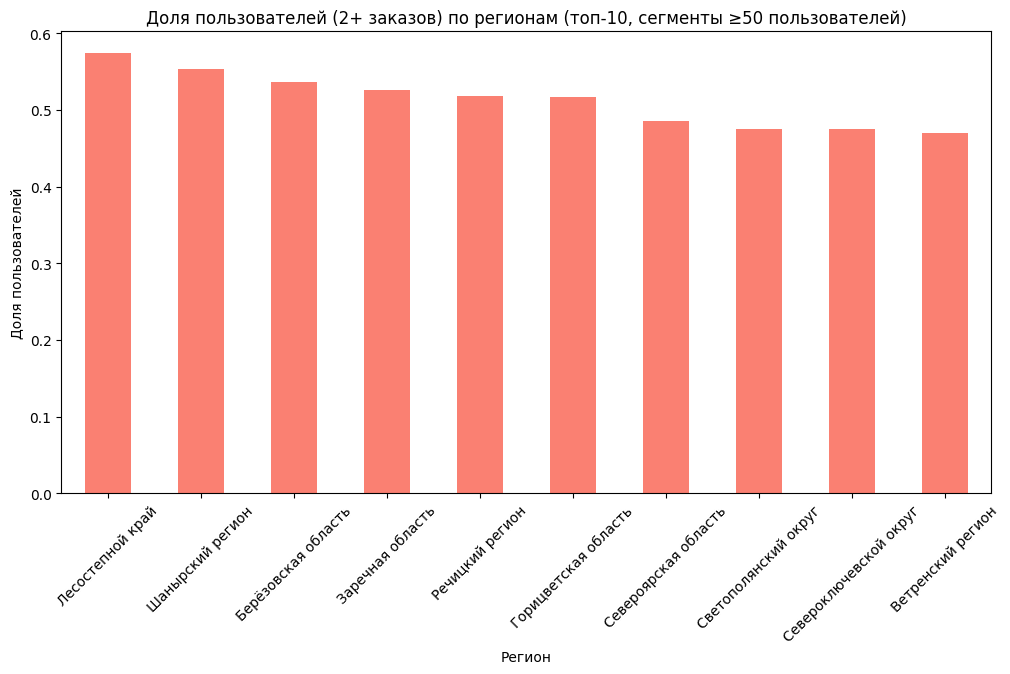

In [37]:
df_user_region = (
    df_user_profile
    .groupby('region_name')
    .agg(
        share_is_two=('is_two', 'mean'),
        users_count=('user_id', 'count')
    )
)

df_user_region = df_user_region[df_user_region['users_count'] >= 50]

df_user_region = df_user_region.sort_values(by='share_is_two', ascending=False)

print(df_user_region)
print(df_user_region.describe())

plt.figure(figsize=(12, 6))
df_user_region['share_is_two'].head(10).plot(kind='bar', color='salmon', rot=45)
plt.title('Доля пользователей (2+ заказов) по регионам (топ-10, сегменты ≥50 пользователей)')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей')
plt.show()

**Анализ влияния сегментов на возврат пользователей (сделали 2 и больше заказов)**

Для корректности выводов были оставлены только сегменты, содержащие больше 50 пользователей

**Тип первого мероприятия**  
Не оказывает значительного влияния на возврат пользователей, значения возвратов по сегментам колеблются от 39 до 46%.

**Тип устройства первой покупки**  
Не оказывает значительного влияния на возврат пользователей, значения возвратов по сегментам колеблются от 44 до 47%.

**Регион проведения мероприятия из первого заказа**
Оказывает ощутимое влияние на возврат пользователей, так, для Лесостепного края, Шанырского региона и Берёзовская области процент возврата пользователей лежит а пределах 54-57%, что значительно выше среднего (42%).

**Билетный оператор, продавший билеты на первый заказ**
Оказывает ощутимое влияние на возврат пользователей, так для операторов Быстрый кассир, Восьмёрка, Край билетов процент возврата пользователей лежит а пределах 52-67%, что значительно выше среднего (46%).

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

Не подтверждается.

Различия между сегментами есть, но небольшие (39–46%).
Концерты показывают средний уровень возврата (45%).
Спорт имеет более низкий показатель (39%) и не превосходит концерты.

**Гипотеза 2.** В крупных регионах выше возврат

Не подтверждается.

Крупнейшие регионы по числу пользователей:
- Каменевский (7000 пользователей, 46%)
- Североярская (3800 пользователей, 49%)

Регионы с максимальным уровенем возврата:
- Лесостепной край (57%, но всего 61 пользователь)
- Шанырский регион (55%, 466 пользователей)
- Берёзовская область (54%, 108 пользователей)
При этом:
крупные регионы демонстрируют средний уровень возврата (45–49%)
максимальные значения достигаются в средних и малых сегментах

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


count     8323.000000
mean       574.026565
std        629.278199
min          0.070000
25%        142.060000
50%        389.650000
75%        844.710000
max      14913.530000
Name: avg_revenue, dtype: float64
count    13239.000000
mean       586.991700
std        512.692861
min          0.352000
25%        281.138125
50%        513.873158
75%        776.789583
max      16738.696667
Name: avg_revenue, dtype: float64


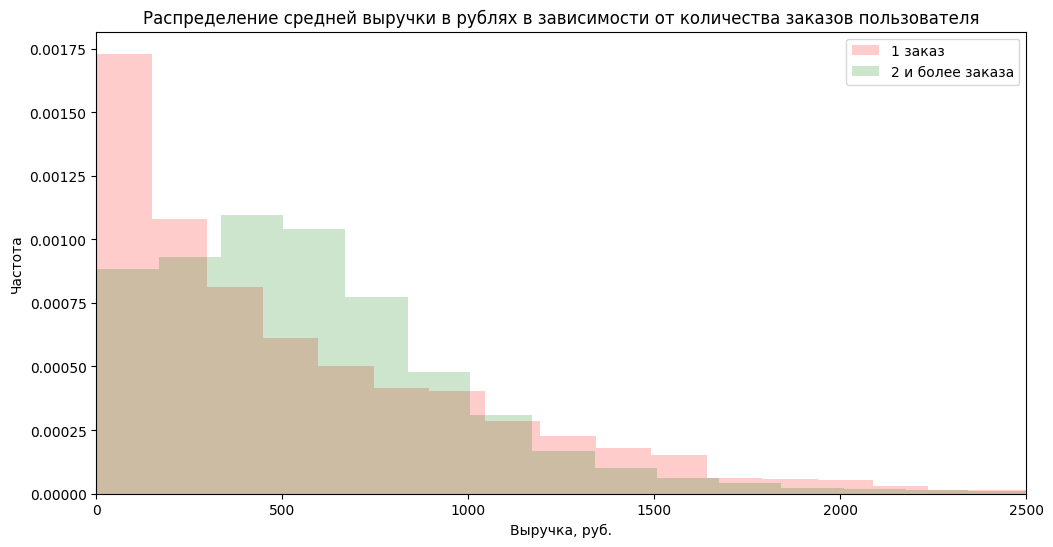

In [38]:
df_1_order = df_user_profile[df_user_profile['total_orders']==1]
df_2_order = df_user_profile[df_user_profile['total_orders']>1]
print(df_1_order['avg_revenue'].describe())
print(df_2_order['avg_revenue'].describe())
plt.figure(figsize=(12, 6))
df_1_order['avg_revenue'].plot(kind='hist', bins=100, color='red', alpha=0.2, label='1 заказ', density=True)
df_2_order['avg_revenue'].plot(kind='hist', bins=100, color='green', alpha=0.2, label='2 и более заказа', density=True)
plt.xlim(0, 2500)
plt.title('Распределение средней выручки в рублях в зависимости от количества заказов пользователя')
plt.xlabel('Выручка, руб.')
plt.ylabel('Частота')
plt.legend()
plt.show()

**Связь средней выручки с вероятностью повторных покупок**  
Для пользователей, совершивших 1 заказ, по сравнению с пользователями, совершившими 2 и более заказа наблдается почти одинаковое среднее (около 580 рублей), однако значительна различается медиана, так она является значительно большей для пользователей с 2 и более заказами (514 vs 390 руб.), это говорит о том, что распределения пользователей, совершивших 1 заказ является более сильно скошенным влево, то есть в сторону с маленькой прибылью. В целом для сегмента пользователей, совершивших 1 заказ распределение менее равномерное, так как стандартное отклонение больше (629 vs 587 руб.)

- Пользователи с низким чеком чаще не возвращаются — дешёвые покупки хуже конвертируются в повторные заказы.
- Привлечение через дешёвые события может давать большой поток пользователей, но с низким retention.
- Более качественный первый опыт (с более высоким чеком) связан с большей вероятностью возврата.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


count     7131.000000
mean       587.109618
std        568.766994
min          2.416667
25%        225.002500
50%        481.505000
75%        817.770000
max      16738.696667
Name: avg_revenue, dtype: float64
count     6108.000000
mean       586.854032
std        438.288444
min          0.352000
25%        347.882750
50%        536.170929
75%        742.614722
max      16475.362143
Name: avg_revenue, dtype: float64


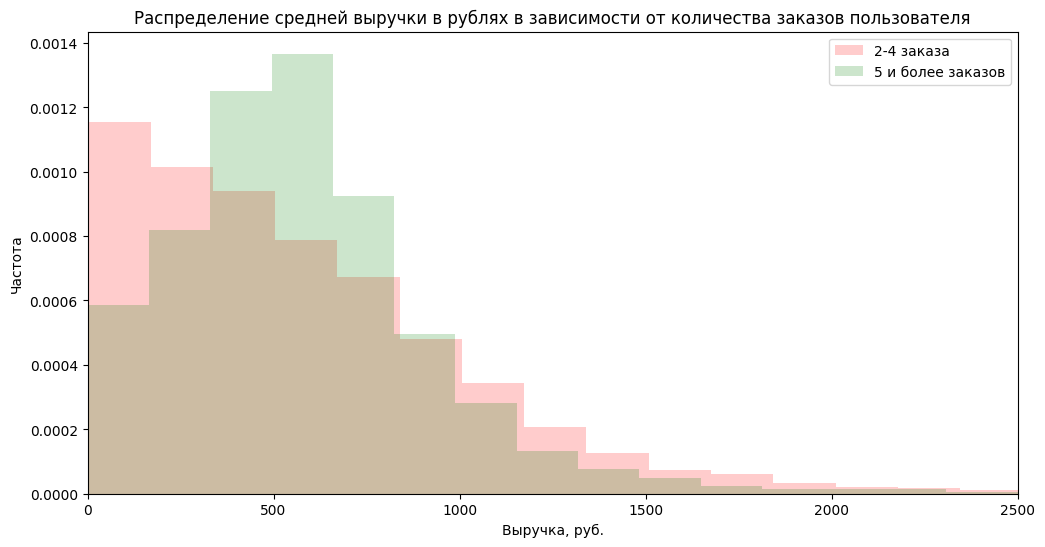

In [39]:
df_2_4_order = df_user_profile[(df_user_profile['total_orders']<=4) & (df_user_profile['total_orders']>=2)]
df_5_order = df_user_profile[df_user_profile['total_orders']>4]
print(df_2_4_order['avg_revenue'].describe())
print(df_5_order['avg_revenue'].describe())
plt.figure(figsize=(12, 6))
df_2_4_order['avg_revenue'].plot(kind='hist', bins=100, color='red', alpha=0.2, label='2-4 заказа', density=True)
df_5_order['avg_revenue'].plot(kind='hist', bins=100, color='green', alpha=0.2, label='5 и более заказов', density=True)
plt.xlim(0, 2500)
plt.title('Распределение средней выручки в рублях в зависимости от количества заказов пользователя')
plt.xlabel('Выручка, руб.')
plt.ylabel('Частота')
plt.legend()
plt.show()

**Анализ средней выручки для клиентов, которые покупали билеты несколько раз**

Распределение средней выручки, для пользователей, совершивших 5 и более заказов более равномерно, чем для пользователей, совершивших 2-4 заказа, а также сильнее смещено в более высокую ценовую категорию, так как имеет большую медиану (536 vs 482 руб.), следовательно:
- 5 и более заказов совершают клиенты, которые чаще всего приносят стабильную среднюю выручку
- 2-4 заказа чаще всего совершают клиенты, которые приносят более вариативную выручку
- 5+ заказов → более стабильный и высокий типичный чек
- 2–4 заказа → более разбросанное поведение и больше дешёвых покупок

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [40]:
df_user_profile['tickets_segment'] = pd.cut(
    df_user_profile['avg_tickets_count'],
    bins=[1, 2, 3, 5, np.inf],
    labels=['1–2', '2–3', '3–5', '5+'],
    right=False 
)
df_user_profile.head()

,user_id,first_order_date,last_order_date,total_orders,avg_revenue,avg_tickets_count,avg_time_between_orders,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five,tickets_segment
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,False,False,3–5
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,False,False,3–5
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,True,False,2–3
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,False,False,3–5
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,False,False,1–2


In [41]:
df_tickets_segmentation = df_user_profile.groupby('tickets_segment').agg(
    total_users=('user_id', 'count'),
    users_retention_share=('is_two', 'mean')
)
print(df_tickets_segmentation)

                 total_users  users_retention_share
tickets_segment                                    
1–2                     2373               0.313527
2–3                     9348               0.587933
3–5                     9156               0.369048
5+                       685               0.078832


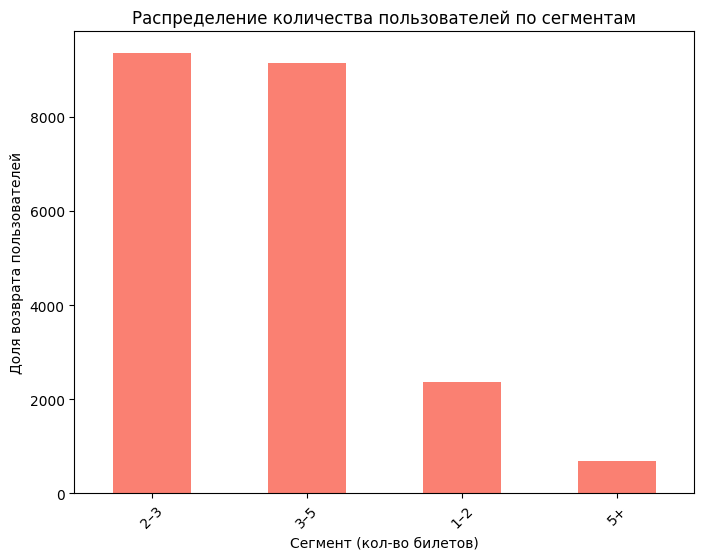

In [42]:
plt.figure(figsize=(8, 6))
df_tickets_segmentation['total_users'].sort_values(ascending=False).plot(kind='bar', color='salmon', rot=45)
plt.title('Распределение количества пользователей по сегментам')
plt.xlabel('Сегмент (кол-во билетов)')
plt.ylabel('Доля возврата пользователей')
plt.show()

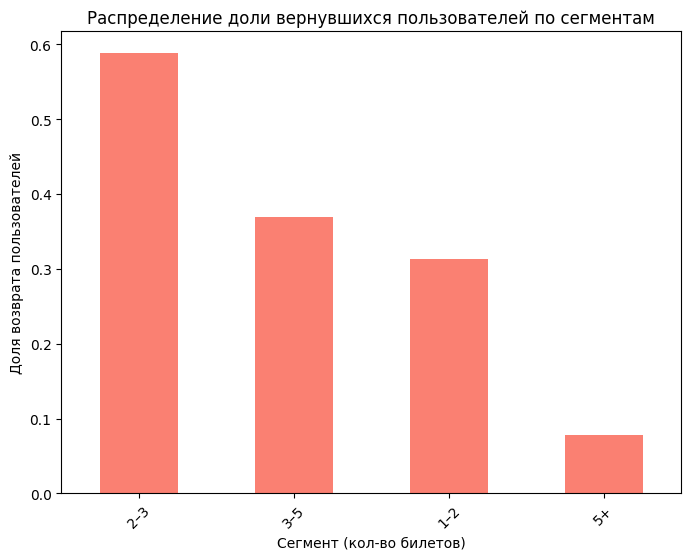

In [43]:
plt.figure(figsize=(8, 6))
df_tickets_segmentation['users_retention_share'].sort_values(ascending=False).plot(kind='bar', color='salmon', rot=45)
plt.title('Распределение доли вернувшихся пользователей по сегментам')
plt.xlabel('Сегмент (кол-во билетов)')
plt.ylabel('Доля возврата пользователей')
plt.show()

**Выводы**
- Пользователи распределены неравномерно: основная масса — в сегментах 2–3 и 3–5 билетов.
- Максимальный retention — в сегменте 2–3 билета (59%).
- В сегментах 1–2 и 3–5 возврат ниже (31–37%).
- Сегмент 5+ билетов показывает аномально низкий retention (~8%), вероятно из-за разовых или групповых покупок.

Зависимость нелинейная:
наибольшая вероятность возврата покупателя при 2–3 билетах,
крайние сегменты связаны с более низким процентом возврата пользователей.



---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [44]:
weekday_map = {
    0: 'понедельник',
    1: 'вторник',
    2: 'среда',
    3: 'четверг',
    4: 'пятница',
    5: 'суббота',
    6: 'воскресенье'
}
df_user_profile['first_order_weekday'] = df_user_profile['first_order_date'].dt.weekday.map(weekday_map)
df_user_profile.head()

,user_id,first_order_date,last_order_date,total_orders,avg_revenue,avg_tickets_count,avg_time_between_orders,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five,tickets_segment,first_order_weekday
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,False,False,3–5,вторник
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,False,False,3–5,вторник
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,True,False,2–3,суббота
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,False,False,3–5,четверг
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,False,False,1–2,воскресенье


first_order_weekday
суббота        1511
вторник        1466
пятница        1426
среда          1378
четверг        1337
понедельник    1333
воскресенье    1222
Name: is_two, dtype: int64


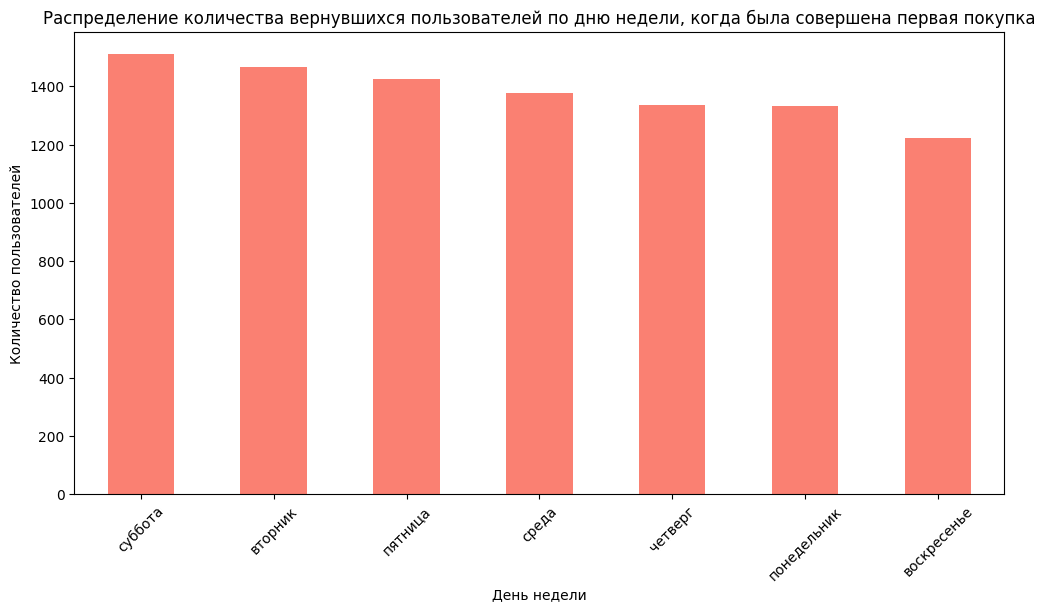

first_order_weekday
вторник        0.460138
понедельник    0.459022
суббота        0.458574
среда          0.450180
воскресенье    0.441793
пятница        0.439716
четверг        0.430319
Name: is_two, dtype: float64


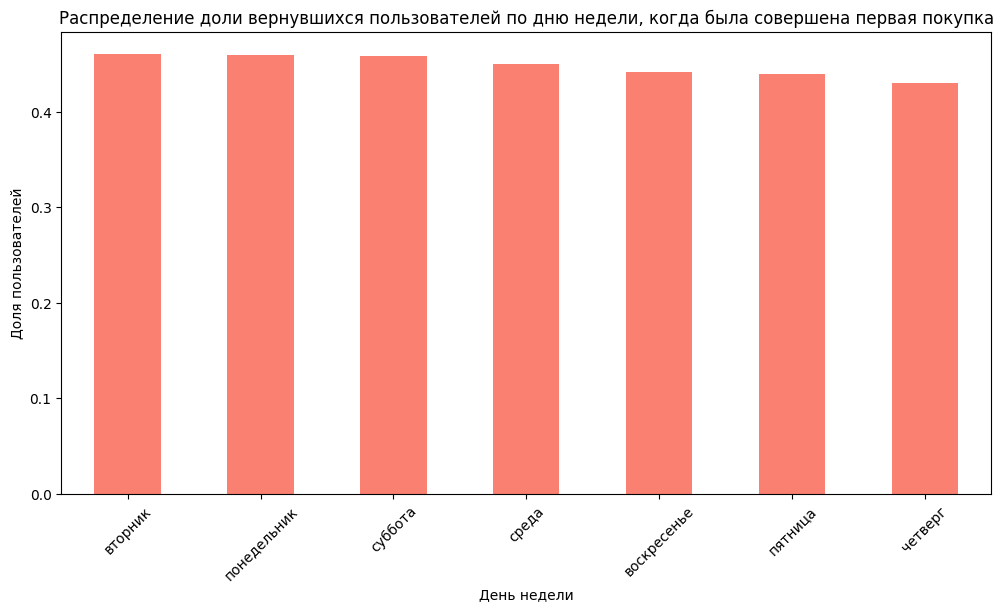

In [45]:
first_order_weekday = df_user_profile.groupby('first_order_weekday')['is_two'].sum().sort_values(ascending=False)

print(first_order_weekday)

plt.figure(figsize=(12, 6))
first_order_weekday.plot(kind='bar', color='salmon', rot=45)
plt.title('Распределение количества вернувшихся пользователей по дню недели, когда была совершена первая покупка')
plt.xlabel('День недели')
plt.ylabel('Количество пользователей')
plt.show()

first_order_weekday_share = df_user_profile.groupby('first_order_weekday')['is_two'].mean().sort_values(ascending=False)

print(first_order_weekday_share)

plt.figure(figsize=(12, 6))
first_order_weekday_share.plot(kind='bar', color='salmon', rot=45)
plt.title('Распределение доли вернувшихся пользователей по дню недели, когда была совершена первая покупка')
plt.xlabel('День недели')
plt.ylabel('Доля пользователей')
plt.show()

In [46]:
today = pd.Timestamp.today().normalize()
df_user_profile['lifetime_days'] = (
    today - df_user_profile['first_order_date']
).dt.days
df_user_profile.head()

,user_id,first_order_date,last_order_date,total_orders,avg_revenue,avg_tickets_count,avg_time_between_orders,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five,tickets_segment,first_order_weekday,lifetime_days
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,False,False,3–5,вторник,605
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,False,False,3–5,вторник,633
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,True,False,2–3,суббота,643
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,False,False,3–5,четверг,610
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,False,False,1–2,воскресенье,565


count    21562.000000
mean       614.128188
std         47.960676
min        533.000000
25%        571.000000
50%        615.000000
75%        660.000000
max        685.000000
Name: lifetime_days, dtype: float64


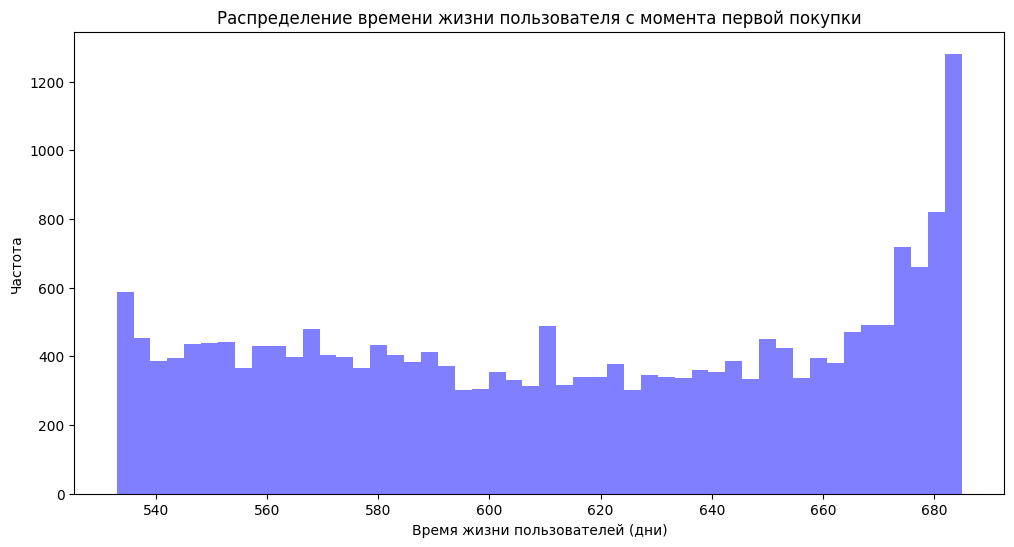

In [47]:
plt.figure(figsize=(12,6))
print(df_user_profile['lifetime_days'].describe())
df_user_profile['lifetime_days'].plot(kind='hist', color='blue', alpha=0.5, bins=50)
plt.title('Распределение времени жизни пользователя с момента первой покупки')
plt.xlabel('Время жизни пользователей (дни)')
plt.ylabel('Частота')
plt.show()

count    13278.000000
mean        16.125158
std         22.387051
min          0.000000
25%          1.333333
50%          8.411765
75%         21.000000
max        148.000000
Name: avg_time_between_orders, dtype: float64


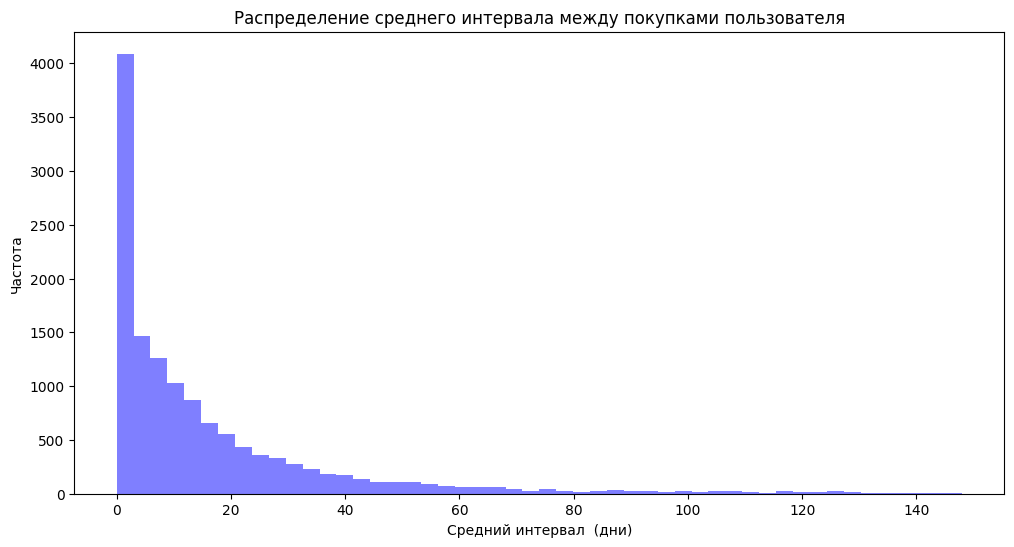

In [48]:
plt.figure(figsize=(12,6))
print(df_user_profile['avg_time_between_orders'].describe())
df_user_profile['avg_time_between_orders'].plot(kind='hist', color='blue', alpha=0.5, bins=50)
plt.title('Распределение среднего интервала между покупками пользователя')
plt.xlabel('Средний интервал  (дни)')
plt.ylabel('Частота')
plt.show()

**Анализ влияния дня недели первой покупки на вероятность возврата клиента**

День недели первой покупки не оказывает статистически значимого влияния на вероятность возврата пользователя, так как распределение доли вернувшихся пользователей в зависимости от дня недели колеблется незначительно, от 43 до 46%.

**Распределение времени жизни пользователей**

- Средний лайфтайм: 614 дней =
- Небольшой разброс (48 дней)
- Узкий диапазон значений (533–685 дней)

**Вывод:**  
Пользовательская база сформирована в один период.

**Распределение интервала между покупками**

- Средний интервал: ~16 дней, медиана: ~8.4 дня
- Высокий разброс (std ≈ 22 дня)
- Значительная асимметрия распределения (длинный правый хвост)

**Вывод:**  
Выделяются два сегмента пользователей:  
- частые покупатели (основной вклад в выручку)  
- редкие покупатели (потенциал для реактивации)

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [49]:
df_2_4_orders = df_user_profile[(df_user_profile['total_orders']>=2) & (df_user_profile['total_orders']<=4)]
df_5_orders = df_user_profile[df_user_profile['total_orders']>=5]
avg_time_between_orders_2_4 = df_2_4_orders['avg_time_between_orders'].mean()
avg_time_between_orders_5 = df_5_orders['avg_time_between_orders'].mean()
print('Среднее время между заказами для пользователей, совершивших 2-4 заказа')
print(f'{avg_time_between_orders_2_4:.2f} дней')
print('Среднее время между заказами для пользователей, совершивших 5 и более заказов')
print(f'{avg_time_between_orders_5.mean():.2f} дней')

Среднее время между заказами для пользователей, совершивших 2-4 заказа
21.23 дней
Среднее время между заказами для пользователей, совершивших 5 и более заказов
9.95 дней


In [1]:
plt.figure(figsize=(12, 8))
min_value = df_user_profile['avg_time_between_orders'].min()
max_value = df_user_profile['avg_time_between_orders'].max()
bins = range(int(min_value), int(max_value)+1, 5)
df_2_4_orders['avg_time_between_orders'].plot(kind='hist', color='blue', alpha=0.2, label='2-4 заказа', bins=bins, density=True)
df_5_orders['avg_time_between_orders'].plot(kind='hist', color='green', alpha=0.2, label='5+ заказов', bins=bins, density=True)
plt.xlabel('Среднее время между заказами пользователей в днях')
plt.ylabel('Частота')
plt.title('Распределение среднего время между заказами пользователей для пользователей с разным количеством заказов')
plt.legend()
plt.show()

NameError: name 'plt' is not defined

**Анализ влияния среднего интервала между заказами в разрезе пользователя на вероятность повторного заказа**

Средний интервал оказывает значительное влияние на вероятность повторного заказа, так как для пользователей, совершивших 5 и более заказов значительно меньше (9.95 дней), чем для для пользователей, совершивших 2-4 заказа (21.23 дней).

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [50]:
df_for_corr = df_user_profile.drop(columns=['user_id'])
interval_cols = [
    'total_orders',
    'avg_revenue',
    'avg_tickets_count',
    'avg_time_between_orders',
    'lifetime_days'
]
phik_matrix = df_for_corr.phik_matrix(interval_cols=interval_cols)
total_orders_corr = phik_matrix['total_orders'].sort_values(ascending=False)
total_orders_corr = total_orders_corr.drop('total_orders')
print('Матрица корреляции между признаками профиля пользователя и числом заказов')
print(total_orders_corr)

Матрица корреляции между признаками профиля пользователя и числом заказов
is_five                    0.683157
is_two                     0.428790
lifetime_days              0.422713
first_order_date           0.419143
last_order_date            0.409977
avg_time_between_orders    0.282985
avg_tickets_count          0.249911
tickets_segment            0.198542
region_name                0.118289
first_order_weekday        0.054461
device_type_canonical      0.021874
event_type_main            0.019823
avg_revenue                0.000000
service_name               0.000000
Name: total_orders, dtype: float64


In [51]:
df_user_profile['total_orders'].describe()

count    21562.000000
mean         6.445784
std         14.098916
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        152.000000
Name: total_orders, dtype: float64

In [52]:
df_user_profile['order_segments'] = pd.cut(df_user_profile['total_orders'], 
                                           bins=[0, 1, 4, float('inf')], labels=['1', '2-4', '5+'])
df_user_profile.head()

,user_id,first_order_date,last_order_date,total_orders,avg_revenue,avg_tickets_count,avg_time_between_orders,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five,tickets_segment,first_order_weekday,lifetime_days,order_segments
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,False,False,3–5,вторник,605,1
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,False,False,3–5,вторник,633,2-4
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,True,False,2–3,суббота,643,2-4
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,False,False,3–5,четверг,610,1
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,False,False,1–2,воскресенье,565,2-4


Матрица корреляции между признаками профиля пользователя и сегментироавнным числом заказов
last_order_date            0.606088
first_order_date           0.576929
lifetime_days              0.472169
avg_tickets_count          0.404287
avg_time_between_orders    0.397584
tickets_segment            0.222575
region_name                0.126946
avg_revenue                0.081095
service_name               0.076387
event_type_main            0.041272
first_order_weekday        0.031609
device_type_canonical      0.017665
Name: order_segments, dtype: float64


Text(0.5, 1.0, 'Матрица корреляции между признаками профиля пользователя и сегментироавнным числом заказов order_segments')

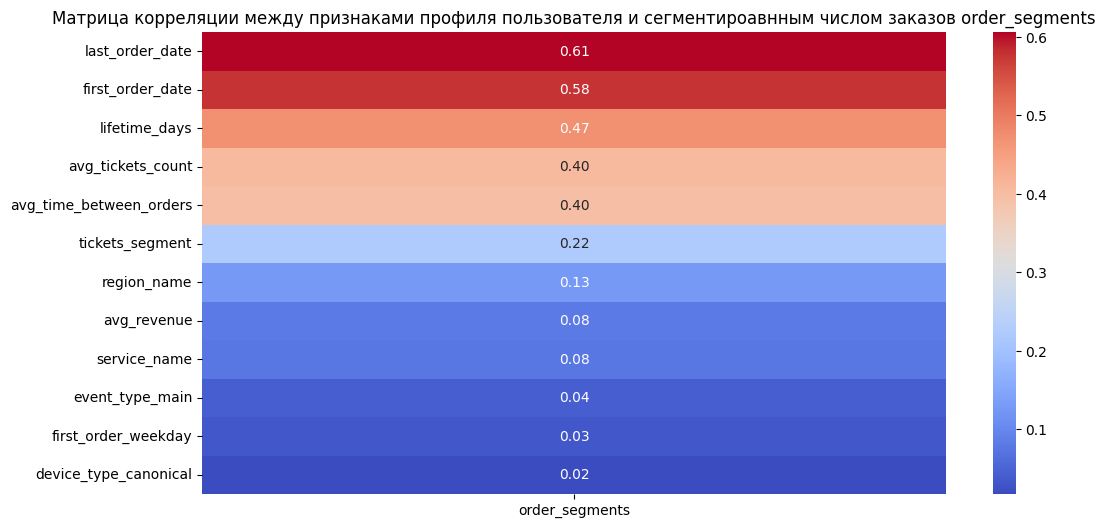

In [53]:
df_for_corr = df_user_profile.drop(columns=['user_id'])
interval_cols = [
    'total_orders',
    'avg_revenue',
    'avg_tickets_count',
    'avg_time_between_orders',
    'lifetime_days'
]
phik_matrix = df_for_corr.phik_matrix(interval_cols=interval_cols)
total_orders_corr = phik_matrix['order_segments'].sort_values(ascending=False)
total_orders_corr = total_orders_corr.drop(['order_segments', 'total_orders', 'is_five', 'is_two'])
print('Матрица корреляции между признаками профиля пользователя и сегментироавнным числом заказов')
print(total_orders_corr)
plt.figure(figsize=(12, 6))
sns.heatmap(total_orders_corr.to_frame(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляции между признаками профиля пользователя и сегментироавнным числом заказов order_segments')

**Анализ корреляции признаков профиля пользователя с сегментироавнным числом заказов**

Наиболее значимую корреляцию с числом заказов показывают признаки: last_order_date, first_order_date и lifetime_days.

- Количество заказов в первую очередь связано с временем жизни пользователя: чем дольше пользователь с сервисом, тем больше заказов.

- Поведенческие факторы (частота покупок и количество билетов) оказывают умеренное влияние.

- Категориальные признаки (регион, устройство, тип события) практически не влияют на число заказов.


### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

### 5. Общий вывод и рекомендации

#### Данные и подготовка

Анализ выполнен на пользовательском датафрейме `df_user_profile` (21 562 пользователя), агрегированном на основе истории заказов.

В ходе подготовки данных:
- объединены данные заказов и пользовательских характеристик;
- выполнена фильтрация выбросов в `total_orders`;
- значения выручки приведены к единой валюте (тенге → рубли);
- рассчитаны агрегированные метрики (средний чек, количество билетов, интервалы между заказами);
- добавлены временные признаки (лайфтайм, день недели первой покупки);
- выполнена сегментация пользователей по числу заказов и количеству билетов;
- проверены и исключены явные дубликаты.

---

#### Описание признаков

- `user_id` — уникальный идентификатор пользователя  
- `first_order_date` — дата первого заказа  
- `last_order_date` — дата последнего заказа  
- `total_orders` — общее количество заказов пользователя  
- `avg_revenue` — средняя выручка с одного заказа  
- `avg_tickets_count` — среднее количество билетов в заказе  
- `avg_time_between_orders` — средний интервал между заказами (в днях, только для пользователей с ≥2 заказами)  
- `device_type_canonical` — устройство, с которого был сделан первый заказ  
- `region_name` — регион первого заказа  
- `service_name` — билетный оператор первого заказа  
- `event_type_main` — тип мероприятия первого заказа  
- `is_two` — пользователь совершил 2 и более заказа  
- `is_five` — пользователь совершил 5 и более заказов  
- `tickets_segment` — сегмент по количеству билетов в заказе  
- `first_order_weekday` — день недели первого заказа  
- `lifetime_days` — время с первой покупки до текущей даты  
- `order_segments` — сегмент по количеству заказов (1, 2–4, 5+)  

---

#### Основные результаты анализа

**1. Точки входа в продукт**

Привлечение пользователей концентрируется в ограниченном числе сегментов:
- 45% пользователей совершают первый заказ на концерты;
- 83% пользователей приходят с мобильных устройств;
- значительная доля заказов сосредоточена в нескольких регионах и у 3–5 ключевых операторов.

→ Продукт привлекает пользователей неравномерно, а через конкретные каналы и категории.

---

**2. Факторы возврата пользователей**

- Тип события, устройство и регион **оказывают минимальное влияние на возврат** (39–47%);
- Регион и билетный оператор оказывают **существенное влияние**:
  - лучшие регионы: до 54–57% возврата (при среднем ~42%);
  - лучшие операторы: до 52–67% (при среднем ~46%).

→ Качество опыта (оператор, локальный рынок) важнее типа события.

---

**3. Поведенческие факторы**

- Максимальный retention у пользователей с **2–3 билетами (до 59%)**, вероятно регулярный семейный досуг;
- Сегмент 5+ билетов имеет крайне низкий retention (~8%) → вероятно, разовые групповые покупки;
- Пользователи с более высоким первым чеком возвращаются чаще;
- Средний чек у лояльных пользователей выше и стабильнее.

→ Возврат связан с “типом потребления”.

---

**4. Частота покупок**

- Медианный интервал между покупками — ~8 дней, при среднем ~16 дней и высокой вариативности;
- Распределение асимметрично: большая часть пользователей совершает повторную покупку достаточно быстро, но присутствует длинный хвост пользователей с большими интервалами.

- По результатам корреляционного анализа наблюдается ** связь между интервалом между покупками и количеством заказов**:
  - пользователи с меньшим интервалом между покупками совершают больше заказов;
  - пользователи с длинными интервалами чаще остаются на уровне 1–2 заказов.

→ Это указывает на формирование поведенческого паттерна:  
**чем быстрее пользователь совершает вторую покупку, тем выше вероятность, что он станет регулярным клиентом.**

→ Таким образом, интервал между покупками выступает не просто метрикой активности, а **ранним индикатором будущей лояльности пользователя**.

---

**5. Временные характеристики**

- Лайфтайм практически одинаков у всех пользователей → база сформирована в один период;
- День недели первой покупки не влияет на возврат.

---

**6. Корреляционный анализ**

- Основной драйвер числа заказов — лайфтайм;
- Умеренная связь — частота покупок и размер заказа;
- Категориальные признаки (регион, устройство, тип события) практически не влияют.

→ Рост заказов определяется поведением пользователя, а не его характеристиками.

---

#### Бизнес-рекомендации

**1. Сфокусировать удержание на сегменте 1–2 заказа**

Проблема: большинство пользователей не переходит к повторным покупкам.

Решение:
- запуск триггерных коммуникаций после первой покупки;
- предложения на похожие события в течение 7–10 дней (с учётом медианного интервала);
- фокус на пользователях с низким первым чеком (наиболее рискованный сегмент).

---

**2. Развивать “оптимальный сценарий потребления” (2–3 билета)**

Наблюдение: максимальный retention у пользователей с 2–3 билетами.

Гипотеза:
- это небольшие группы (друзья, семьи), которые регулярно посещают мероприятия.

Решение:
- стимулировать покупку 2–3 билетов (семейные скидки);
- рекомендовать “идти вместе”;
- таргетировать групповые сценарии.

---

**3. Пересмотреть стратегию привлечения через дешёвые события**

Наблюдение:
- пользователи с низким revenue хуже возвращаются.

Риск:
- привлечение дешёвого трафика с низким возвратом.

Решение:
- сместить фокус на события среднего ценового сегмента;

---

**4. Использовать сильные регионы и операторов**

Наблюдение:
- различия в retention до 20% 

Решение:
- масштабировать успешные практики операторов с высоким retention;
- изучить лучшие регионы как бенчмарк;
- перераспределить маркетинговый бюджет в пользу более эффективных каналов.

---

**5. Оптимизировать мобильный канал как основной**

Наблюдение:
- 83% пользователей приходят с мобильных устройств.

Решение:
- приоритет UX и скорости покупки на mobile;
- мобильные персонализированные рекомендации;
- push-уведомления как основной канал возврата.

---

**6. Реактивация “редких” пользователей**

Наблюдение:
- часть пользователей имеет длинные интервалы между покупками.

Решение:
- таргетированные кампании на пользователей с интервалом > 14 дней;
- напоминания и персональные предложения.

---

#### Итог

Рост числа заказов можно обеспечить за счёт:
- формирования правильного сценария потребления (2–3 билета) с использованием акций, направленных на групповое потребление;
- сокращения времени до второй покупки с помощью пуш-уведомлений, скидок и т.д.;
- работы с качеством первого опыта через анализ стартегии наиболее эффективных билетных операторов и проработку UX-дизайна мобильного приложения;
- масштабирования стратегии успешных каналов привлечения (операторы, регионы, mobile).

**Ссылка на проект в github:** https://github.com/danilalebedev/yandex_second_module_final_project/tree/main

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**